# Гребень подвздошной кости: три метода и голосование

Один ноутбук, который для каждой стороны (левый/правый гребень) отвечает на два вопроса: **есть ли гребень в кадре** и **где точка**.
Решение «есть / нет» принимают **три независимых метода голосованием (2 из 3)**:

1. **Keypoint-модель** (ConvNeXt-Tiny, победитель сравнения backbone) — heatmap + голова присутствия. Она же ставит координату точки.
2. **Классификатор «гребень в окне: да/нет»** — отдельная модель на нижнем боковом окне со стёртым позвоночником.
3. **Математика** — доля яркой кости у нижнего края окна, без обучения (порог подбирается по разметке).

Точка ставится, только если проголосовали «есть» минимум два метода из трёх; координату даёт keypoint-модель.

## Позвоночник вырезается аккуратно

Классификатор и математика смотрят только на боковое окно (нижняя треть кадра, `SIDE_FRAC` ширины от края). Позвоночник внутри окна
**закрашивается нулями построчно по маске столба** (+ запас 9 px) — даже если он искривлён и заходит в окно, до методов он не доходит.
Обоснование по данным: все 189 размеченных гребней лежат в нижней трети и не дальше 0.24 ширины кадра от бокового края, а граница столба
зажата в `[0.28, 0.5]` ширины — крыло под маску не попадает (0 из 189).

## Как оцениваем честно

- **Keypoint:** обучение на фолдах, кроме `VAL_FOLD` и `TEST_FOLD`; эпоха и порог — по `VAL_FOLD`; тест — `TEST_FOLD` (19 снимков, в нём всего 2 стороны без гребня!).
- **Классификатор:** кросс-валидация (OOF), затем финальная модель на всех данных (в прод — только она).
- **Математика:** порог подбирается на фолдах, не входящих в проверяемые (leave-one-image-out для честной оценки).
- **Голосование** оценивается на `TEST_FOLD` и на `VAL_FOLD + TEST_FOLD` (39 снимков; у keypoint на `VAL_FOLD` порог/эпоха выбирались — там чуть оптимистично).
  Негативов в разметке 9 сторон из 198, поэтому цифры по «нет» хрупкие.

## Перед запуском

`training_package` (`images/`) + `pelvis_crest_manifest.csv` — те же, что для остальных ноутбуков. Время: keypoint (60 эпох) + классификатор (5 фолдов × 15 эпох + финальная).

# Часть 1. Keypoint-модель (положение точки + вероятность присутствия)

То же, что в `train_pelvis_crest.ipynb`, но только с победившим backbone.

In [1]:
!pip install -q albumentations timm scikit-learn

In [2]:
import os
import random
import math

import numpy as np
import pandas as pd
import cv2
import albumentations as A
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm

## Воспроизводимость: seed + детерминизм

In [3]:
SEED = 42


def set_full_determinism(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_full_determinism(SEED)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_generator(seed: int = SEED) -> torch.Generator:
    g = torch.Generator()
    g.manual_seed(seed)
    return g

## Конфигурация

In [4]:
# --- ПРАВЬТЕ ПОД СВОЮ СРЕДУ ---
IMAGES_DIR = "/kaggle/input/datasets/cgvhbjmk/dxa-data/training_package/images"
KEYPOINTS_MANIFEST_PATH = "/kaggle/input/datasets/cgvhbjmk/dxa-data/training_package/pelvis_crest_manifest.csv"
OUTPUT_DIR = "./outputs_pelvis_crest"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10
HEAD_LR = 1e-3
BACKBONE_LR = 1e-4  # было 1e-5 при заморозке до layer2 включительно — признаки почти не подстраивались под рентген
TEST_FOLD = 4  # честный отложенный тест (фолд из Step 1, тот же принцип, что в keypoints бедра)
VAL_FOLD = 3   # валидация: ранняя остановка и калибровка порога видимости
NUM_WORKERS = 2

KEYPOINT_NAMES = ["подвздошный_гребень_слева", "подвздошный_гребень_справа"]
HEATMAP_SIGMA = 6.0  # пикселей, в масштабе 224x224
# Анатомический приор (проверен по данным, масштаб 224x224 после аугментации): левый гребень по x не правее 76,
# правый не левее 149, оба не выше y=134 (исходно y/h>=0.686 — нижняя треть, как в классическом детекторе).
# Пик heatmap разрешён только там (с запасом), центр с позвоночником для него закрыт.
CREST_MIN_Y = 120
CREST_LEFT_MAX_X = 92    # левый канал: x < 92
CREST_RIGHT_MIN_X = 132  # правый канал: x >= 132
# Backbone — обычные картинки, не рентген (готовые веса из timm). Замораживается только самый ранний слой
# (общие края/текстуры), имена параметров зависят от семейства. Раньше был resnet18.a1_in1k — нестандартный
# рецепт "ResNet strikes back" (BCE-лосс, тяжёлая аугментация), не классический ImageNet.
#   convnext_tiny.fb_in22k_ft_in1k  — ImageNet-22k (14 млн картинок, 22 тыс. классов) -> ImageNet-1k, по умолчанию
#   resnet18.fb_swsl_ig1b_ft_in1k   — тот же ResNet18, но предобучен на 1 млрд картинок, затем дообучен на ImageNet
#   resnet18.tv_in1k                — классические веса torchvision
BACKBONES = {
    "convnext_tiny.fb_in22k_ft_in1k": ("stem", "stages_0"),
    "resnet18.fb_swsl_ig1b_ft_in1k": ("conv1", "bn1", "layer1"),
    "resnet18.tv_in1k": ("conv1", "bn1", "layer1"),
    "resnet18.a1_in1k": ("conv1", "bn1", "layer1"),
}
BACKBONE_CANDIDATES = [  # в итоговом ноутбуке — только победитель сравнения backbone (см. train_pelvis_crest.ipynb)
    "convnext_tiny.fb_in22k_ft_in1k",
]
PRETRAINED_BACKBONE = True
PRESENCE_LOSS_WEIGHT = 0.2  # вес BCE головы "точка есть/нет" относительно лосса heatmap (угадан)
VISIBILITY_THRESHOLD = 0.9  # используется только для точности присутствия в логе обучения; итоговый порог для каждого
                            # backbone выбирается в ячейке калибровки (chosen_threshold)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Аугментация

Геометрические трансформации (поворот/масштаб/сдвиг/флип по горизонтали —
здесь он допустим и меняет местами левый/правый гребень, см. датасет ниже)
через `A.Compose(..., keypoint_params=...)`, как в keypoints бедра.

In [5]:
def clahe(image: np.ndarray) -> np.ndarray:
    return cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(image)


def build_train_transform(image_size=IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.8),
        A.RandomGamma(gamma_limit=(70, 130), p=0.5),
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.08), p=1.0),
            A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
        ], p=0.4),
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-10, 10), fit_output=False, p=0.7),
        A.HorizontalFlip(p=0.5),  # меняет местами левый/правый гребень — обрабатывается в датасете
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT, fill=0),
    ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False), seed=SEED)


def build_eval_transform(image_size=IMAGE_SIZE) -> A.Compose:
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT, fill=0),
    ], keypoint_params=A.KeypointParams(format="xy", remove_invisible=False))

## Dataset: генерация heatmap на лету

`apply_crest_occlusion` — своя аугментация невидимости для этой задачи
(вместо `apply_crop_augmentation` из keypoints бедра). Два режима, оба
закрашивают чёрным только ОДНУ сторону (левую или правую), никогда не
заходя дальше небольшого запаса `INWARD_MARGIN_PX` в сторону центра —
дополнительно ограничено безопасной полосой `SPINE_SAFETY_FRAC` вокруг
центра кадра. Позвоночник тем самым гарантированно виден целиком до
низа снимка в любом аугментированном примере.

- **`square`** (было и раньше) — маленький квадрат вплотную вокруг
  самой точки: имитирует локальную помеху/лёгкую обрезку края.
- **`full`** — закрашивает ПОПИКСЕЛЬНО настоящую кость с этой стороны:
  flood fill от самой размеченной точки гребня по СЫРОМУ (не-CLAHE)
  изображению (CLAHE неровно усиливает контраст/шум на этих снимках и
  ненадёжна как источник для формы кости — проверено отдельно), пока
  яркость похожа на затравку. Граница закраски у позвоночника повторяет
  реальный неровный контур кости вплотную, без зазора видимой кости и
  без риска задеть рёбра выше неё. Имитирует случай, когда гребень не
  виден потому, что вся эта сторона таза попросту не попала в кадр
  целиком, а не просто заслонена локально.

Сейчас `FULL_OCCLUDE_PROB = 1.0`: используется только `full`. `square` остался
в коде, но не выбирается — он закрывает лишь квадрат, а кость вокруг остаётся
видна, поэтому метка «невидима» для него была ложной.

In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

COORD_COLS = [
    ("greben_levo_x", "greben_levo_y"),
    ("greben_pravo_x", "greben_pravo_y"),
]


def make_gaussian_heatmap(size: int, x: float, y: float, sigma: float) -> np.ndarray:
    yy, xx = np.mgrid[0:size, 0:size]
    heatmap = np.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)


def get_coords_and_visibility(row):
    # Как и в keypoints бедра: отсутствующая точка (NaN) — не грязные
    # данные, а содержательный сигнал ("гребень на этом срезе не виден"),
    # строки с ней не выбрасываются.
    coords, visible = [], []
    for xcol, ycol in COORD_COLS:
        x, y = row[xcol], row[ycol]
        if pd.isna(x) or pd.isna(y):
            coords.append(None)
            visible.append(0)
        else:
            coords.append((float(x), float(y)))
            visible.append(1)
    return coords, visible


OCCLUDE_HALF_MIN_PX = 14
OCCLUDE_HALF_MAX_PX = 30
INWARD_MARGIN_PX = 8       # насколько закрашенная область может зайти В СТОРОНУ столба от самой точки (square-режим)
OCCLUDE_FRACTION = 0.3     # доля строк, для которых добавляем ещё и закрытую копию (как CROP_DUPLICATE_FRACTION у бедра)
FULL_OCCLUDE_PROB = 1.0    # доля аугментированных примеров с режимом "full" (вся кость сбоку от точки вниз).
                           # 1.0 = только full: square оставляет кость видимой, а метка говорит "невидима"
SPINE_BOTTOM_BAND_FRAC = 0.15  # см. классический детектор гребня (pelvis_v2/pelvis_points) —
                                # ширину столба меряем у входа в таз (нижняя полоса), а не по середине
SPINE_NARROW_SAFETY = 4        # небольшой запас поверх измеренной ширины столба (подобрано визуально —
                                # меньше см. историю: было 8, давало заметный зазор до кости)
SPINE_THR_COEF = 0.5           # порог маски столба относительно фона (было 0.35 — недооценивало
                                # реальную ширину и давало слишком широкий отступ до столба)


def _spine_mask_224(image_u8: np.ndarray):
    """Маска столба на 224x224 — тот же приём, что в rib_ridge.spine_mask
    классического детектора: порог от фона по краям кадра, затем берём
    компоненту, содержащую центр кадра по x."""
    sm = cv2.GaussianBlur(image_u8.astype(np.float32), (0, 0), 1.5)
    h, w = image_u8.shape
    cx0, cx1 = int(w * 0.25), int(w * 0.75)
    bg = np.percentile(sm[:, :int(w * 0.12)], 70) if w > 50 else 0
    col = sm[:, cx0:cx1]
    thr = bg + SPINE_THR_COEF * (np.percentile(col, 90) - bg)
    mask = (sm >= thr).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n <= 1:
        return mask.astype(bool)
    best, best_area = 0, 0
    cxx = w // 2
    for k in range(1, n):
        x, y, bw, bh, area = stats[k]
        if x <= cxx <= x + bw and area > best_area:
            best, best_area = k, area
    return labels == best


def _spine_x_bounds(image_u8: np.ndarray):
    """Настоящая граница столба (x_lo, x_hi), а не угаданная доля кадра от
    центра — переиспользуем проверенный приём классического детектора гребня
    (pelvis_points._column_exclude_zone): максимальная ширина столба в нижней
    полосе (там, где он входит в таз и шире всего), плюс небольшой запас."""
    h, w = image_u8.shape
    spine = _spine_mask_224(image_u8)
    ys = np.where(spine.any(axis=1))[0]
    if len(ys) < 10:
        cx = w // 2
        return cx - w // 6, cx + w // 6
    y_lo = ys[-1] - int(SPINE_BOTTOM_BAND_FRAC * (ys[-1] - ys[0]))
    best_width, rows_xs = None, []
    for y in range(y_lo, ys[-1] + 1):
        xs = np.where(spine[y])[0]
        if len(xs) == 0:
            continue
        rows_xs.append((xs.min(), xs.max()))
        width = xs.max() - xs.min()
        if best_width is None or width > best_width:
            best_width = width
    if not rows_xs:
        cx = w // 2
        return cx - w // 6, cx + w // 6
    cx = float(np.mean([(lo + hi) / 2 for lo, hi in rows_xs]))
    half = best_width / 2 + SPINE_NARROW_SAFETY
    return int(cx - half), int(cx + half)
FULL_OCCLUDE_TOP_MARGIN_PX = 6  # небольшой запас ВЫШЕ точки (точка — не всегда самый
                                # верхний пиксель кости, гребень может слегка выступать ещё выше)
SPINE_ROW_MARGIN_PX = 3        # запас от РЕАЛЬНОГО края столба в каждой строке (см. ниже)

# Ручной список снимков, где визуальная проверка показала плохой результат
# закраски (см. review_both.py) — эти стороны НИКОГДА не выбираются целью
# аугментации (ни square, ни full). Естественные (не аугментированные) данные
# по этим снимкам всё равно участвуют в обучении как обычно.
FULL_OCCLUDE_EXCLUDE = {
    "1ab40e61b69ae442c6be051b7b9c1491.png": {"left"},
    "23eac28f7dd0f1c4a2459689b4a53da3.png": {"left", "right"},
    "26625c20719dd1284335ab516ae99971.png": {"right"},
    "29770d24bdf1f02106f04cc0f091f6d2.png": {"left"},
    "480855287efec4ed66e31f979cce396f.png": {"left", "right"},
    "408027217b49c3ca61b7e577918a8d44.png": {"left"},
    "582320894b66922860ac25310168527a.png": {"right"},
    "8680958a504686b8794854836c052b61.png": {"right"},
    "840dc40cb4fa67d575fc295921e081e2.png": {"left", "right"},
    "a3b07df372e1c69c07d2fd1efe793f1e.png": {"right"},
    "b293df24290f52a7837dd3268dae225a.png": {"right"},
    "b42fe6bdd2df1a8e2b6f2b619b1d1adf.png": {"left"},
    "bcf954d28b2217d780926ea310d4cf3d.png": {"right"},
    "be9577a5a6d08707bfb208c1d551a2a9.png": {"left", "right"},
    "c6aa8d320ec79c579f3ebb449c1e34e6.png": {"right"},
    "cdc320d488ad762459a12c7faedae0ec.png": {"right"},
    "ee986ce85c9f2e12222b072b6f081402.png": {"right"},
    "3f1a9b33e27d1d44f1af5051430c961d.png": {"left", "right"},
}


TOP_EDGE_TILT_PX_PER_PX = 0.35  # верхний край закраски идёт по диагонали, а не прямой
                                 # горизонтальной линией: гребень обычно ВЫШЕ у столба и
                                 # НИЖЕ к боковому краю кадра — наклон имитирует эту форму
                                 # и заодно убирает "рисованную" ровную полосу на стыке


def _below_point_mask(image_u8: np.ndarray, seed_x: float, seed_y: float, side: str,
                       fallback_lo: int, fallback_hi: int):
    """Область ОТ ТОЧКИ И НИЖЕ — но верхний край не прямая горизонтальная линия
    (см. TOP_EDGE_TILT_PX_PER_PX: наклон в зависимости от расстояния по x до точки),
    а внутренняя граница (у столба) подстраивается ПОД КАЖДУЮ СТРОКУ ОТДЕЛЬНО по
    настоящей маске столба (_spine_mask_224): там, где столб уже — закраска подходит
    ближе; там, где шире — не задевает его. Строка без обнаруженного столба (редко,
    шум) берёт границу БЛИЖАЙШЕЙ СОСЕДНЕЙ строки, а длинный хвост без обнаружения
    (обычно у самого низа кадра) продолжает НАКЛОН последних найденных строк вместо
    плоской "полки". Fallback используется, только если столб не найден вообще
    ни в одной строке закрашиваемой области."""
    size = image_u8.shape[0]
    y0 = max(0, int(round(seed_y)) - FULL_OCCLUDE_TOP_MARGIN_PX)
    MAX_JITTER_PX = 11  # верхняя оценка амплитуды "ряби" ниже — цикл должен захватывать
                         # и эти более высокие строки, иначе рябь физически недостижима
    y_scan0 = max(0, y0 - MAX_JITTER_PX)
    spine = _spine_mask_224(image_u8)

    edges = np.full(size, -1, dtype=int)
    for y in range(y_scan0, size):
        xs = np.where(spine[y])[0]
        if len(xs):
            edges[y] = int(xs.min()) - SPINE_ROW_MARGIN_PX if side == "left"                 else int(xs.max()) + 1 + SPINE_ROW_MARGIN_PX

    valid = np.where(edges[y_scan0:] >= 0)[0] + y_scan0
    if len(valid) == 0:
        edges[y0:] = fallback_lo if side == "left" else fallback_hi
    else:
        # одиночные пропуски (шум) — просто берём соседнюю строку;
        # ДЛИННЫЙ хвост без обнаружения (обычно у самого низа кадра, где столб
        # переходит в крестец и контраст другой) — не держим плоской "полкой"
        # до конца (это и давало ровную горизонтальную линию), а продолжаем
        # НАКЛОН последних найденных строк, как и было до пропуска
        last = edges[valid[0]]
        for y in range(y_scan0, size):
            if edges[y] >= 0:
                last = edges[y]
            else:
                edges[y] = last
        TREND_K = 12  # по скольким последним найденным строкам считаем наклон
        gap_start = valid[-1] + 1
        if gap_start < size and len(valid) >= 2:
            k = min(TREND_K, len(valid))
            ys_fit = valid[-k:]
            xs_fit = edges[ys_fit]
            slope = float(np.polyfit(ys_fit, xs_fit, 1)[0])
            slope = float(np.clip(slope, -2.0, 2.0))  # без резких скачков наклона
            base = edges[gap_start - 1]
            for y in range(gap_start, size):
                edges[y] = int(round(base + slope * (y - (gap_start - 1))))

    # верхний край: БАЗОВЫЙ уровень — от точки (y0) гарантированно покрыт в любом
    # столбце (точка никогда не остаётся видимой). Поверх — органическая "рябь",
    # детерминированная по x (не случайная от вызова к вызову, но и не одна прямая
    # линия): волна только ДОБАВЛЯЕТ покрытие выше y0, никогда не отнимает его —
    # безопасно и одновременно убирает "нарисованный" ровный край.
    mask = np.zeros((size, size), dtype=bool)
    for y in range(y_scan0, size):
        e = edges[y]
        if side == "left":
            e = max(0, e)
            xs_range = range(0, e)
        else:
            e = min(size, e)
            xs_range = range(e, size)
        for x in xs_range:
            jitter = abs(6 * math.sin(0.18 * (x + seed_x)) + 4 * math.sin(0.41 * (x + seed_x) + 1.3))
            col_y0 = y0 - int(round(jitter))
            if y >= col_y0:
                mask[y, x] = True
    return mask


def expand_with_occlusion_duplicates(df: pd.DataFrame, fraction: float = OCCLUDE_FRACTION, seed: int = SEED) -> pd.DataFrame:
    """Тот же приём, что и у keypoints бедра: ВСЕ строки остаются как есть
    (force_occlude=0), и ДОПОЛНИТЕЛЬНО для случайной доли строк добавляется
    ещё одна закрытая копия (force_occlude=1). Доля намеренно меньше
    половины — на инференсе подавляющее большинство снимков видят гребень
    нормально, 50/50 сделало бы модель неоправданно "пугливой".
    """
    clean = df.copy()
    clean["force_occlude"] = 0
    subset = df.sample(frac=fraction, random_state=seed)
    occluded = subset.copy()
    occluded["force_occlude"] = 1
    return pd.concat([clean, occluded], ignore_index=True)


def force_occlude_all(df: pd.DataFrame) -> pd.DataFrame:
    """Как force_crop_all у бедра: полностью закрытая копия для синтетической
    проверки детекции невидимости на val/test отдельно от натуральных метрик."""
    out = df.copy()
    out["force_occlude"] = 1
    return out


def apply_crest_occlusion(image: np.ndarray, coords_224: list, visible: list,
                           disallow_sides: set = frozenset()):
    """Закрашивает чёрным ОДНУ сторону снимка (левую или правую, случайно
    выбранную из видимых гребней) - режимом "square" (маленький квадрат
    у точки) или "full" (вся полоса СНИЗУ от точки, до низа кадра — см.
    _below_point_mask). Ни один режим не заходит дальше INWARD_MARGIN_PX
    в сторону центра - столб гарантированно виден целиком до низа снимка.
    `disallow_sides` — стороны ("left"/"right"), которые аугментация НИКОГДА
    не должна закрашивать на этом снимке (см. FULL_OCCLUDE_EXCLUDE — ручной
    список по итогам визуальной проверки): такая сторона вообще не участвует
    в выборе цели, ни square, ни full её не тронут."""
    size = image.shape[0]
    center = size / 2
    spine_x_lo, spine_x_hi = _spine_x_bounds(image)  # настоящая граница столба, не угаданная доля кадра

    def _side_of(x):
        return "left" if x < center else "right"

    visible_idx = [i for i, v in enumerate(visible) if v == 1 and coords_224[i] is not None
                   and _side_of(coords_224[i][0]) not in disallow_sides]
    if not visible_idx:
        return image, coords_224, visible

    target_i = random.choice(visible_idx)
    px, py = coords_224[target_i]
    full_mode = random.random() < FULL_OCCLUDE_PROB

    if px < center:  # точка слева от центра — столб справа
        x0 = 0
        # full: внутренняя граница — ВПЛОТНУЮ до настоящего столба (spine_x_lo);
        # square: внутренняя граница — совсем небольшой запас от точки (INWARD_MARGIN_PX)
        x1 = spine_x_lo if full_mode else min(px + INWARD_MARGIN_PX, spine_x_lo)
        if not full_mode:
            x0 = max(0, px - random.uniform(OCCLUDE_HALF_MIN_PX, OCCLUDE_HALF_MAX_PX))
        x1 = max(x1, x0 + 1)
    else:  # точка справа — столб слева
        x1 = size
        x0 = spine_x_hi if full_mode else max(px - INWARD_MARGIN_PX, spine_x_hi)
        if not full_mode:
            x1 = min(size, px + random.uniform(OCCLUDE_HALF_MIN_PX, OCCLUDE_HALF_MAX_PX))
        x0 = min(x0, x1 - 1)

    image = image.copy()
    new_visible = list(visible)
    new_coords = list(coords_224)

    if full_mode:
        # закрашиваем СНИЗУ от точки, до низа кадра, с границей у столба, которая
        # подстраивается под каждую строку отдельно (см. _below_point_mask) —
        # ближе там, где столб уже, без риска задеть его там, где шире.
        side = "left" if px < center else "right"
        mask = _below_point_mask(image, px, py, side, spine_x_lo, spine_x_hi)
        image[mask] = 0
        # видимость проверяем по маленькой окрестности точки (не по одному пикселю) —
        # Otsu-маска не идеально сплошная (дырки на тёмных участках трабекулярной
        # кости), формальный промах ровно в дырку не должен оставлять точку "видимой"
        PT_CHECK_RADIUS = 4
        for i, c in enumerate(coords_224):
            if c is not None:
                cx, cy = int(round(c[0])), int(round(c[1]))
                y0c, y1c = max(0, cy - PT_CHECK_RADIUS), min(mask.shape[0], cy + PT_CHECK_RADIUS + 1)
                x0c, x1c = max(0, cx - PT_CHECK_RADIUS), min(mask.shape[1], cx + PT_CHECK_RADIUS + 1)
                if y1c > y0c and x1c > x0c and mask[y0c:y1c, x0c:x1c].any():
                    new_visible[i] = 0
                    new_coords[i] = None
    else:
        half_y = random.uniform(OCCLUDE_HALF_MIN_PX, OCCLUDE_HALF_MAX_PX)
        y0 = max(0, int(py - half_y))
        y1 = min(size, int(py + half_y))
        x0, x1 = int(x0), int(x1)
        image[y0:y1, x0:x1] = 0
        for i, c in enumerate(coords_224):
            if c is not None and x0 <= c[0] < x1 and y0 <= c[1] < y1:
                new_visible[i] = 0
                new_coords[i] = None

    return image, new_coords, new_visible


class PelvisCrestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, images_dir: str, train: bool, force_occlude_eval: bool = False):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.train = train
        self.force_occlude_eval = force_occlude_eval  # синтетическая проверка на val/test, не аугментация обучения

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.images_dir, row["image_filename"])
        image_u8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image_u8 is None:
            raise FileNotFoundError(f"Не удалось прочитать {path}")
        image_u8 = clahe(image_u8)

        coords, visible = get_coords_and_visibility(row)
        present_idx = [i for i, c in enumerate(coords) if c is not None]
        present_pts = [coords[i] for i in present_idx]

        transform = build_train_transform() if self.train else build_eval_transform()
        transformed = transform(image=image_u8, keypoints=present_pts)
        image_t = transformed["image"]
        pts_t = transformed["keypoints"]

        # Канал определяется ПОЛОЖЕНИЕМ точки (x < центра — левый, иначе правый), а не исходным
        # индексом: HorizontalFlip меняет стороны местами, и одиночная точка (вторая не размечена)
        # иначе осталась бы в "чужом" канале. Гребни далеко от центра — сторона однозначна.
        coords_224 = [None, None]
        visible = [0, 0]
        for pt in pts_t:
            ch = 0 if pt[0] < IMAGE_SIZE / 2 else 1
            coords_224[ch] = (float(pt[0]), float(pt[1]))
            visible[ch] = 1

        if (self.train or self.force_occlude_eval) and int(row.get("force_occlude", 0)) == 1:
            disallow_sides = FULL_OCCLUDE_EXCLUDE.get(row["image_filename"], set())
            image_t, coords_224, visible = apply_crest_occlusion(image_t, coords_224, visible, disallow_sides)

        heatmaps = np.stack([
            make_gaussian_heatmap(IMAGE_SIZE, c[0], c[1], HEATMAP_SIGMA) if c is not None
            else np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)
            for c in coords_224
        ], axis=0)

        rgb = np.stack([image_t] * 3, axis=-1).astype(np.float32) / 255.0
        rgb = (rgb - IMAGENET_MEAN) / IMAGENET_STD
        image_tensor = torch.from_numpy(rgb.transpose(2, 0, 1)).float()
        heatmap_tensor = torch.from_numpy(heatmaps).float()

        coords_tensor = torch.tensor(
            [c if c is not None else (-1.0, -1.0) for c in coords_224], dtype=torch.float32
        )
        visible_tensor = torch.tensor(visible, dtype=torch.float32)

        return image_tensor, heatmap_tensor, coords_tensor, visible_tensor


manifest = pd.read_csv(KEYPOINTS_MANIFEST_PATH)
coord_cols_flat = [c for pair in COORD_COLS for c in pair]
n_fully_visible = manifest[coord_cols_flat].notna().all(axis=1).sum()
print(f"Строк всего: {len(manifest)}, оба гребня видны: {n_fully_visible}")
print("Строки с невидимым гребнем НЕ выбрасываются — это тоже обучающий сигнал.")
for xcol, ycol in COORD_COLS:
    n_missing = manifest[xcol].isna().sum()
    print(f"  {xcol.rsplit(chr(95),1)[0]}: невидим на {n_missing} снимках")

train_manifest = manifest[~manifest["fold"].isin([VAL_FOLD, TEST_FOLD])].reset_index(drop=True)
val_manifest = manifest[manifest["fold"] == VAL_FOLD].reset_index(drop=True)
test_manifest = manifest[manifest["fold"] == TEST_FOLD].reset_index(drop=True)
print()
print(f"обучение: {len(train_manifest)}, валидация: {len(val_manifest)}, отложенный тест: {len(test_manifest)}")

Строк всего: 99, оба гребня видны: 94
Строки с невидимым гребнем НЕ выбрасываются — это тоже обучающий сигнал.
  greben_levo: невидим на 4 снимках
  greben_pravo: невидим на 5 снимках

обучение: 60, валидация: 20, отложенный тест: 19


## Модель: backbone (один из `BACKBONE_CANDIDATES`) + decoder до heatmap + голова присутствия

- **Heatmap** отвечает только на «где»: левый канал видит только `x < CREST_LEFT_MAX_X`, правый только
  `x >= CREST_RIGHT_MIN_X`, оба ниже `CREST_MIN_Y` (вне области логит принудительно -20). Так пик не может
  оказаться на рёбрах, позвоночнике или другой стороне; границы взяты из данных (см. конфигурацию).
- **Голова присутствия** отвечает на «есть ли точка вообще» (BCE, метка 0/1 после аугментации закрытия). Решение
  «видна / не видна» принимается по ней, а не по высоте пика heatmap — высота пика на этих данных не различала
  видимую и закрытую точку.

In [7]:
class KeypointHeatmapModel(nn.Module):
    def __init__(self, num_keypoints: int = 2, backbone_name: str = None):
        super().__init__()
        backbone_name = backbone_name or BACKBONE_CANDIDATES[0]
        self.encoder = timm.create_model(backbone_name, pretrained=PRETRAINED_BACKBONE, features_only=True)
        feat_ch = self.encoder.feature_info.channels()[-1]  # каналы последнего этапа (stride 32)
        for name, param in self.encoder.named_parameters():
            if name.startswith(BACKBONES[backbone_name]):
                param.requires_grad = False

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(feat_ch, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
        )
        self.head = nn.Conv2d(32, num_keypoints, kernel_size=1)

        # Допустимая область пика (приор из конфигурации): вне неё логит = -20, то есть пик там
        # невозможен и в лоссе (цель там всегда 0), и на инференсе. Не сохраняется в чекпоинт.
        assert num_keypoints == 2, "маска рассчитана на левый/правый гребень"
        allowed = torch.zeros(1, 2, IMAGE_SIZE, IMAGE_SIZE, dtype=torch.bool)
        allowed[:, 0, CREST_MIN_Y:, :CREST_LEFT_MAX_X] = True
        allowed[:, 1, CREST_MIN_Y:, CREST_RIGHT_MIN_X:] = True
        self.register_buffer("allowed_region", allowed, persistent=False)

        # Голова присутствия: "точка есть/нет" отдельно от положения. Считается по признакам той же
        # области кадра, где допустим пик (левый низ / правый низ), avg+max пулинг -> 1 логит на точку.
        self.presence = nn.ModuleList([nn.Linear(2 * feat_ch, 1), nn.Linear(2 * feat_ch, 1)])

    @staticmethod
    def _pool(region):
        return torch.cat([region.mean(dim=(2, 3)), region.amax(dim=(2, 3))], dim=1)

    def forward(self, x):
        feat = self.encoder(x)[-1]  # последний этап backbone, stride 32 (7x7 при 224)
        d = self.decoder(feat)
        logits = self.head(d).masked_fill(~self.allowed_region, -20.0)  # heatmap-логиты, sigmoid снаружи

        fh, fw = feat.shape[-2:]
        r0 = int(CREST_MIN_Y / IMAGE_SIZE * fh)
        left = feat[:, :, r0:, : int(CREST_LEFT_MAX_X / IMAGE_SIZE * fw) + 1]
        right = feat[:, :, r0:, int(CREST_RIGHT_MIN_X / IMAGE_SIZE * fw):]
        presence_logits = torch.cat([self.presence[0](self._pool(left)), self.presence[1](self._pool(right))], dim=1)
        return logits, presence_logits  # (B,2,H,W), (B,2)

## Цикл обучения

`weighted_heatmap_loss` — тот же приём, что у keypoints бедра: обычный
MSE на почти полностью нулевой heatmap тривиально "решается" предсказанием
нуля везде, поэтому пиксели рядом с истинной точкой взвешены сильнее
(`POS_WEIGHT`).

In [8]:
POS_WEIGHT = 25.0


def weighted_heatmap_loss(pred_logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred = torch.sigmoid(pred_logits)
    weight = 1.0 + (POS_WEIGHT - 1.0) * target
    return (weight * (pred - target) ** 2).mean()


def build_optimizer(model: nn.Module):
    head_params = (list(model.decoder.parameters()) + list(model.head.parameters())
                   + list(model.presence.parameters()))
    backbone_params = [p for p in model.encoder.parameters() if p.requires_grad]
    return torch.optim.AdamW([
        {"params": head_params, "lr": HEAD_LR},
        {"params": backbone_params, "lr": BACKBONE_LR},
    ], weight_decay=0.01)


def presence_loss(presence_logits: torch.Tensor, visible: torch.Tensor) -> torch.Tensor:
    return nn.functional.binary_cross_entropy_with_logits(presence_logits, visible)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_px_err, n_px, n = 0.0, 0.0, 0, 0
    n_correct, n_points = 0, 0

    with torch.set_grad_enabled(is_train):
        for images, heatmaps, coords, visible in loader:
            images, heatmaps, visible_t = images.to(DEVICE), heatmaps.to(DEVICE), visible.to(DEVICE)
            hm_logits, pres_logits = model(images)
            loss = weighted_heatmap_loss(hm_logits, heatmaps) + PRESENCE_LOSS_WEIGHT * presence_loss(pres_logits, visible_t)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            with torch.no_grad():
                probs = torch.sigmoid(hm_logits).cpu().numpy()
                coords_np, visible_np = coords.numpy(), visible.numpy()
                for b in range(probs.shape[0]):
                    for k in range(probs.shape[1]):
                        if visible_np[b, k] == 1:
                            y, x = np.unravel_index(np.argmax(probs[b, k]), probs[b, k].shape)
                            total_px_err += math.hypot(x - coords_np[b, k, 0], y - coords_np[b, k, 1])
                            n_px += 1
                pred_present = (torch.sigmoid(pres_logits) >= VISIBILITY_THRESHOLD).float()
                n_correct += int((pred_present == visible_t).sum().item())
                n_points += visible_t.numel()

            bs = images.size(0)
            total_loss += loss.item() * bs
            n += bs

    mean_px_err = total_px_err / n_px if n_px else float("nan")
    return total_loss / n, mean_px_err, n_correct / n_points


def ckpt_path(backbone_name: str) -> str:
    return os.path.join(OUTPUT_DIR, f"pelvis_crest_{backbone_name}.pt")


def train_model(train_manifest: pd.DataFrame, val_manifest: pd.DataFrame, backbone_name: str):
    set_full_determinism(SEED)
    train_df = expand_with_occlusion_duplicates(train_manifest)

    train_ds = PelvisCrestDataset(train_df, IMAGES_DIR, train=True)
    val_ds = PelvisCrestDataset(val_manifest, IMAGES_DIR, train=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                               drop_last=True, worker_init_fn=worker_init_fn, generator=make_generator(SEED))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = KeypointHeatmapModel(num_keypoints=len(KEYPOINT_NAMES), backbone_name=backbone_name).to(DEVICE)
    optimizer = build_optimizer(model)

    best_loss, best_state, patience = float("inf"), None, 0
    for epoch in range(NUM_EPOCHS):
        train_loss, train_err, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_err, val_acc = run_epoch(model, val_loader)
        print(f"epoch {epoch+1}/{NUM_EPOCHS} | train_loss={train_loss:.4f} err={train_err:.1f}px acc={train_acc:.2f} "
              f"| val_loss={val_loss:.4f} err={val_err:.1f}px acc={val_acc:.2f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print(f"early stopping на эпохе {epoch+1}")
                break

    torch.save({"model_state_dict": best_state, "image_size": IMAGE_SIZE, "best_val_loss": best_loss,
                "backbone_name": backbone_name}, ckpt_path(backbone_name))
    return best_loss

## Запуск обучения

Обучаются по очереди все `BACKBONE_CANDIDATES` (один и тот же seed, разбиение и аугментации). Для каждого
сохраняется лучшая по `val_loss` эпоха в `pelvis_crest_<backbone>.pt`.

In [9]:
best_val_losses = {}
for name in BACKBONE_CANDIDATES:
    print("\n" + "#" * 10, name, "#" * 10)
    best_val_losses[name] = train_model(train_manifest, val_manifest, name)
print("\nлучшая val_loss по backbone:", {k: round(v, 4) for k, v in best_val_losses.items()})


########## convnext_tiny.fb_in22k_ft_in1k ##########


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

epoch 1/60 | train_loss=0.0931 err=56.6px acc=0.78 | val_loss=0.1049 err=93.8px acc=0.55
epoch 2/60 | train_loss=0.0377 err=24.1px acc=0.93 | val_loss=0.1913 err=30.3px acc=0.95
epoch 3/60 | train_loss=0.0492 err=23.7px acc=0.90 | val_loss=0.1084 err=16.7px acc=0.93
epoch 4/60 | train_loss=0.0199 err=16.5px acc=0.98 | val_loss=0.1417 err=16.7px acc=0.95
epoch 5/60 | train_loss=0.0156 err=13.2px acc=0.99 | val_loss=0.1416 err=26.8px acc=0.95
epoch 6/60 | train_loss=0.0205 err=11.9px acc=0.99 | val_loss=0.1264 err=18.8px acc=0.85
epoch 7/60 | train_loss=0.0227 err=12.8px acc=0.95 | val_loss=0.2062 err=29.4px acc=0.95
epoch 8/60 | train_loss=0.0211 err=15.2px acc=0.99 | val_loss=0.1560 err=16.4px acc=0.95
epoch 9/60 | train_loss=0.0154 err=14.4px acc=0.97 | val_loss=0.0927 err=17.6px acc=0.95
epoch 10/60 | train_loss=0.0091 err=10.9px acc=0.99 | val_loss=0.1446 err=16.3px acc=0.95
epoch 11/60 | train_loss=0.0081 err=10.1px acc=1.00 | val_loss=0.1366 err=16.9px acc=0.95
epoch 12/60 | train

## Калибровка порога видимости (для каждого backbone)

Считаем на `VAL_FOLD`: естественные данные и синтетику (`force_occlude_all` — закрыта одна сторона режимом `full`).
Порог применяется к **вероятности присутствия** из головы «точка есть/нет». Для каждого backbone порог выбирается
автоматически по синтетике — тот, где выше среднее полноты видимых и невидимых (`chosen_threshold`; если таких
несколько, берётся середина плато); естественных
невидимых на `val` всего 1–4, для выбора порога они слишком малочисленны.

Точность здесь не главная метрика (невидимых ~5%, «всегда видна» уже даёт ~95%): смотрите на **AUC** и на **полноту
по невидимым/видимым**.

In [10]:
from sklearn.metrics import roc_auc_score

THRESHOLDS = (0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99)


def load_model(backbone_name: str):
    ckpt = torch.load(ckpt_path(backbone_name), map_location=DEVICE, weights_only=False)
    m = KeypointHeatmapModel(num_keypoints=len(KEYPOINT_NAMES), backbone_name=backbone_name).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m


def collect_predictions(model, df: pd.DataFrame, force_occlude: bool = False):
    """Вероятность присутствия точки (голова "есть/нет") и ошибка положения пика heatmap (argmax) по видимым."""
    df_eval = force_occlude_all(df) if force_occlude else df
    ds = PelvisCrestDataset(df_eval, IMAGES_DIR, train=False, force_occlude_eval=force_occlude)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    true_vis, scores, errs = [], [], []
    with torch.no_grad():
        for images, heatmaps, coords, visible in loader:
            hm_logits, pres_logits = model(images.to(DEVICE))
            hm = torch.sigmoid(hm_logits).cpu().numpy()
            pres = torch.sigmoid(pres_logits).cpu().numpy()
            coords_np, visible_np = coords.numpy(), visible.numpy()
            for b in range(hm.shape[0]):
                for k in range(hm.shape[1]):
                    true_vis.append(int(visible_np[b, k]))
                    scores.append(float(pres[b, k]))
                    if visible_np[b, k] == 1:
                        y, x = np.unravel_index(np.argmax(hm[b, k]), hm[b, k].shape)
                        errs.append(math.hypot(x - coords_np[b, k, 0], y - coords_np[b, k, 1]))
    return np.array(true_vis), np.array(scores), np.array(errs)


def balanced_accuracy(true_vis, scores, thr):
    """(среднее полноты видимых и невидимых, полнота видимых, полнота невидимых) при пороге thr."""
    pred_vis = scores >= thr
    rec_vis = float(pred_vis[true_vis == 1].mean()) if (true_vis == 1).any() else float("nan")
    rec_inv = float((~pred_vis[true_vis == 0]).mean()) if (true_vis == 0).any() else float("nan")
    return (rec_vis + rec_inv) / 2, rec_vis, rec_inv


def choose_threshold(true_vis, scores):
    """Порог с лучшей сбалансированной точностью. Если таких несколько (плато — оценки присутствия
    прижаты к 0 и 1, и пороги внутри дают одно и то же), берём СЕРЕДИНУ плато, а не край: крайний
    порог отсекает настоящие точки с оценкой чуть ниже него."""
    ba = [balanced_accuracy(true_vis, scores, t)[0] for t in THRESHOLDS]
    best = [t for t, b in zip(THRESHOLDS, ba) if b >= max(ba) - 1e-9]
    return best[(len(best) - 1) // 2]


def report(name, true_vis, scores, errs, thresholds=THRESHOLDS):
    n_vis, n_inv = int(true_vis.sum()), int((1 - true_vis).sum())
    print(f"{name}: {len(true_vis)} точек, видимых {n_vis}, невидимых {n_inv}")
    if n_vis and n_inv:
        print(f"  AUC оценки присутствия (видимая vs невидимая): {roc_auc_score(true_vis, scores):.3f}")
    if len(errs):
        print(f"  ошибка положения пика по видимым: медиана {np.median(errs):.1f}px, среднее {np.mean(errs):.1f}px "
              f"(масштаб {IMAGE_SIZE}x{IMAGE_SIZE})")
    print("  порог | полнота видимых | полнота невидимых | точность")
    for thr in thresholds:
        pred_vis = scores >= thr
        rec_vis = pred_vis[true_vis == 1].mean() if n_vis else float("nan")
        rec_inv = (~pred_vis[true_vis == 0]).mean() if n_inv else float("nan")
        acc = (pred_vis.astype(int) == true_vis).mean()
        print(f"  {thr:5.2f} | {rec_vis:15.3f} | {rec_inv:17.3f} | {acc:.3f}")


chosen_threshold = {}
for name in BACKBONE_CANDIDATES:
    print("\n" + "#" * 10, name, "#" * 10)
    m = load_model(name)
    report("Естественная валидация", *collect_predictions(m, val_manifest))
    syn = collect_predictions(m, val_manifest, force_occlude=True)
    print()
    report("Синтетика (force_occlude_all, full)", *syn)
    chosen_threshold[name] = choose_threshold(syn[0], syn[1])
    print(f"-> порог по синтетике (лучшая сбалансированная точность): {chosen_threshold[name]}")
    del m


########## convnext_tiny.fb_in22k_ft_in1k ##########
Естественная валидация: 40 точек, видимых 36, невидимых 4
  AUC оценки присутствия (видимая vs невидимая): 0.910
  ошибка положения пика по видимым: медиана 16.3px, среднее 17.6px (масштаб 224x224)
  порог | полнота видимых | полнота невидимых | точность
   0.30 |           1.000 |             0.500 | 0.950
   0.50 |           1.000 |             0.500 | 0.950
   0.70 |           1.000 |             0.500 | 0.950
   0.80 |           1.000 |             0.500 | 0.950
   0.90 |           1.000 |             0.500 | 0.950
   0.95 |           1.000 |             0.500 | 0.950
   0.97 |           1.000 |             0.750 | 0.975
   0.99 |           0.972 |             0.750 | 0.950

Синтетика (force_occlude_all, full): 40 точек, видимых 20, невидимых 20
  AUC оценки присутствия (видимая vs невидимая): 0.985
  ошибка положения пика по видимым: медиана 23.1px, среднее 23.2px (масштаб 224x224)
  порог | полнота видимых | полнота невидимых 

## Финальная оценка и сравнение backbone на отложенном тесте

Порог каждого backbone взят из калибровки на `VAL_FOLD` (`chosen_threshold`), тест в выборе порога и эпохи не
участвовал. Таблица сохраняется в `backbone_comparison_test.csv`.

In [11]:
rows = []
for name in BACKBONE_CANDIDATES:
    m = load_model(name)
    thr = chosen_threshold[name]
    tv, sc, er = collect_predictions(m, test_manifest)
    tvs, scs, ers = collect_predictions(m, test_manifest, force_occlude=True)
    ba, rv_syn, ri_syn = balanced_accuracy(tvs, scs, thr)
    rows.append({
        "backbone": name,
        "порог (по val)": thr,
        "ошибка, медиана px": np.median(er),
        "ошибка, среднее px": np.mean(er),
        "видимые найдены (естеств.)": balanced_accuracy(tv, sc, thr)[1],
        "AUC синтетика": roc_auc_score(tvs, scs),
        "видимые найдены (синт.)": rv_syn,
        "закрытые найдены (синт.)": ri_syn,
        "сбаланс. точность (синт.)": ba,
    })
    del m
summary = pd.DataFrame(rows).set_index("backbone")
pd.set_option("display.width", 250)
print(summary.round(3).T.to_string())
summary.round(4).to_csv(os.path.join(OUTPUT_DIR, "backbone_comparison_test.csv"))

backbone                    convnext_tiny.fb_in22k_ft_in1k
порог (по val)                                       0.970
ошибка, медиана px                                  15.499
ошибка, среднее px                                  19.138
видимые найдены (естеств.)                           1.000
AUC синтетика                                        1.000
видимые найдены (синт.)                              1.000
закрытые найдены (синт.)                             0.947
сбаланс. точность (синт.)                            0.974


## Визуализация предсказаний на тесте

Зелёный круг — разметка (видимый гребень). Крест — предсказание положения (максимум heatmap), рисуется только если
вероятность присутствия из головы «точка есть» не ниже порога этого backbone (`chosen_threshold`, 0 или 1 крест на точку): красный `Л` —
левая точка, голубой `П` — правая. В подписи — вероятности присутствия (`Л 0.xx / П 0.xx`). Чтобы увидеть, где стоит
пик у отвергнутых точек, передайте `show_below_threshold=True` (такие кресты серые).
Для каждого backbone два рисунка (естественные данные; закрыта одна сторона — у всех backbone закрыты одни и те же). Второй — тот же тест с закрытой одной стороной (`full`): у закрытой стороны зелёного круга нет, и хорошо,
если креста там тоже нет.

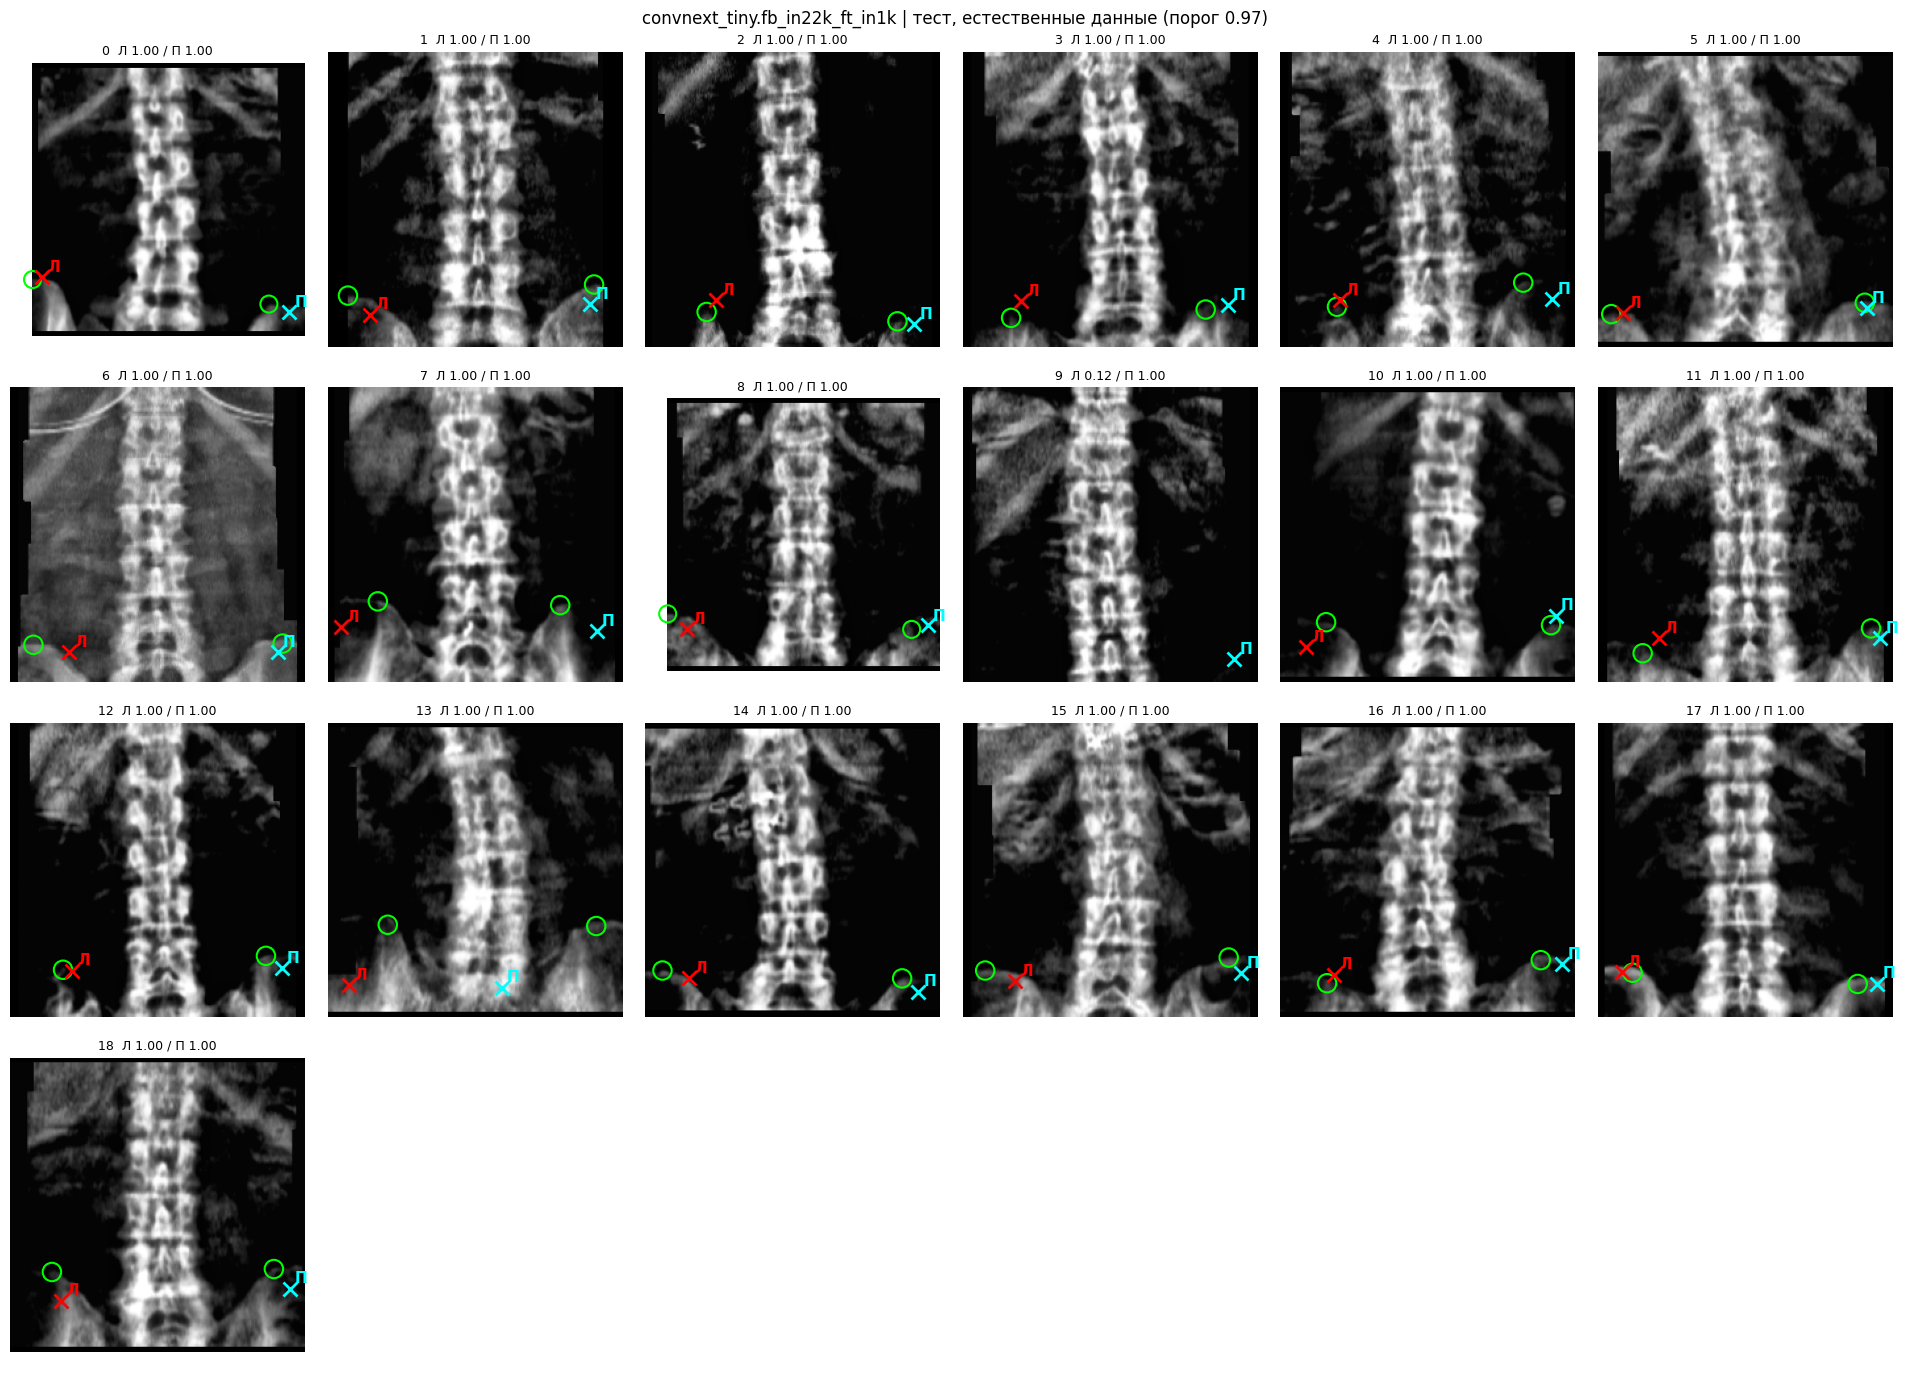

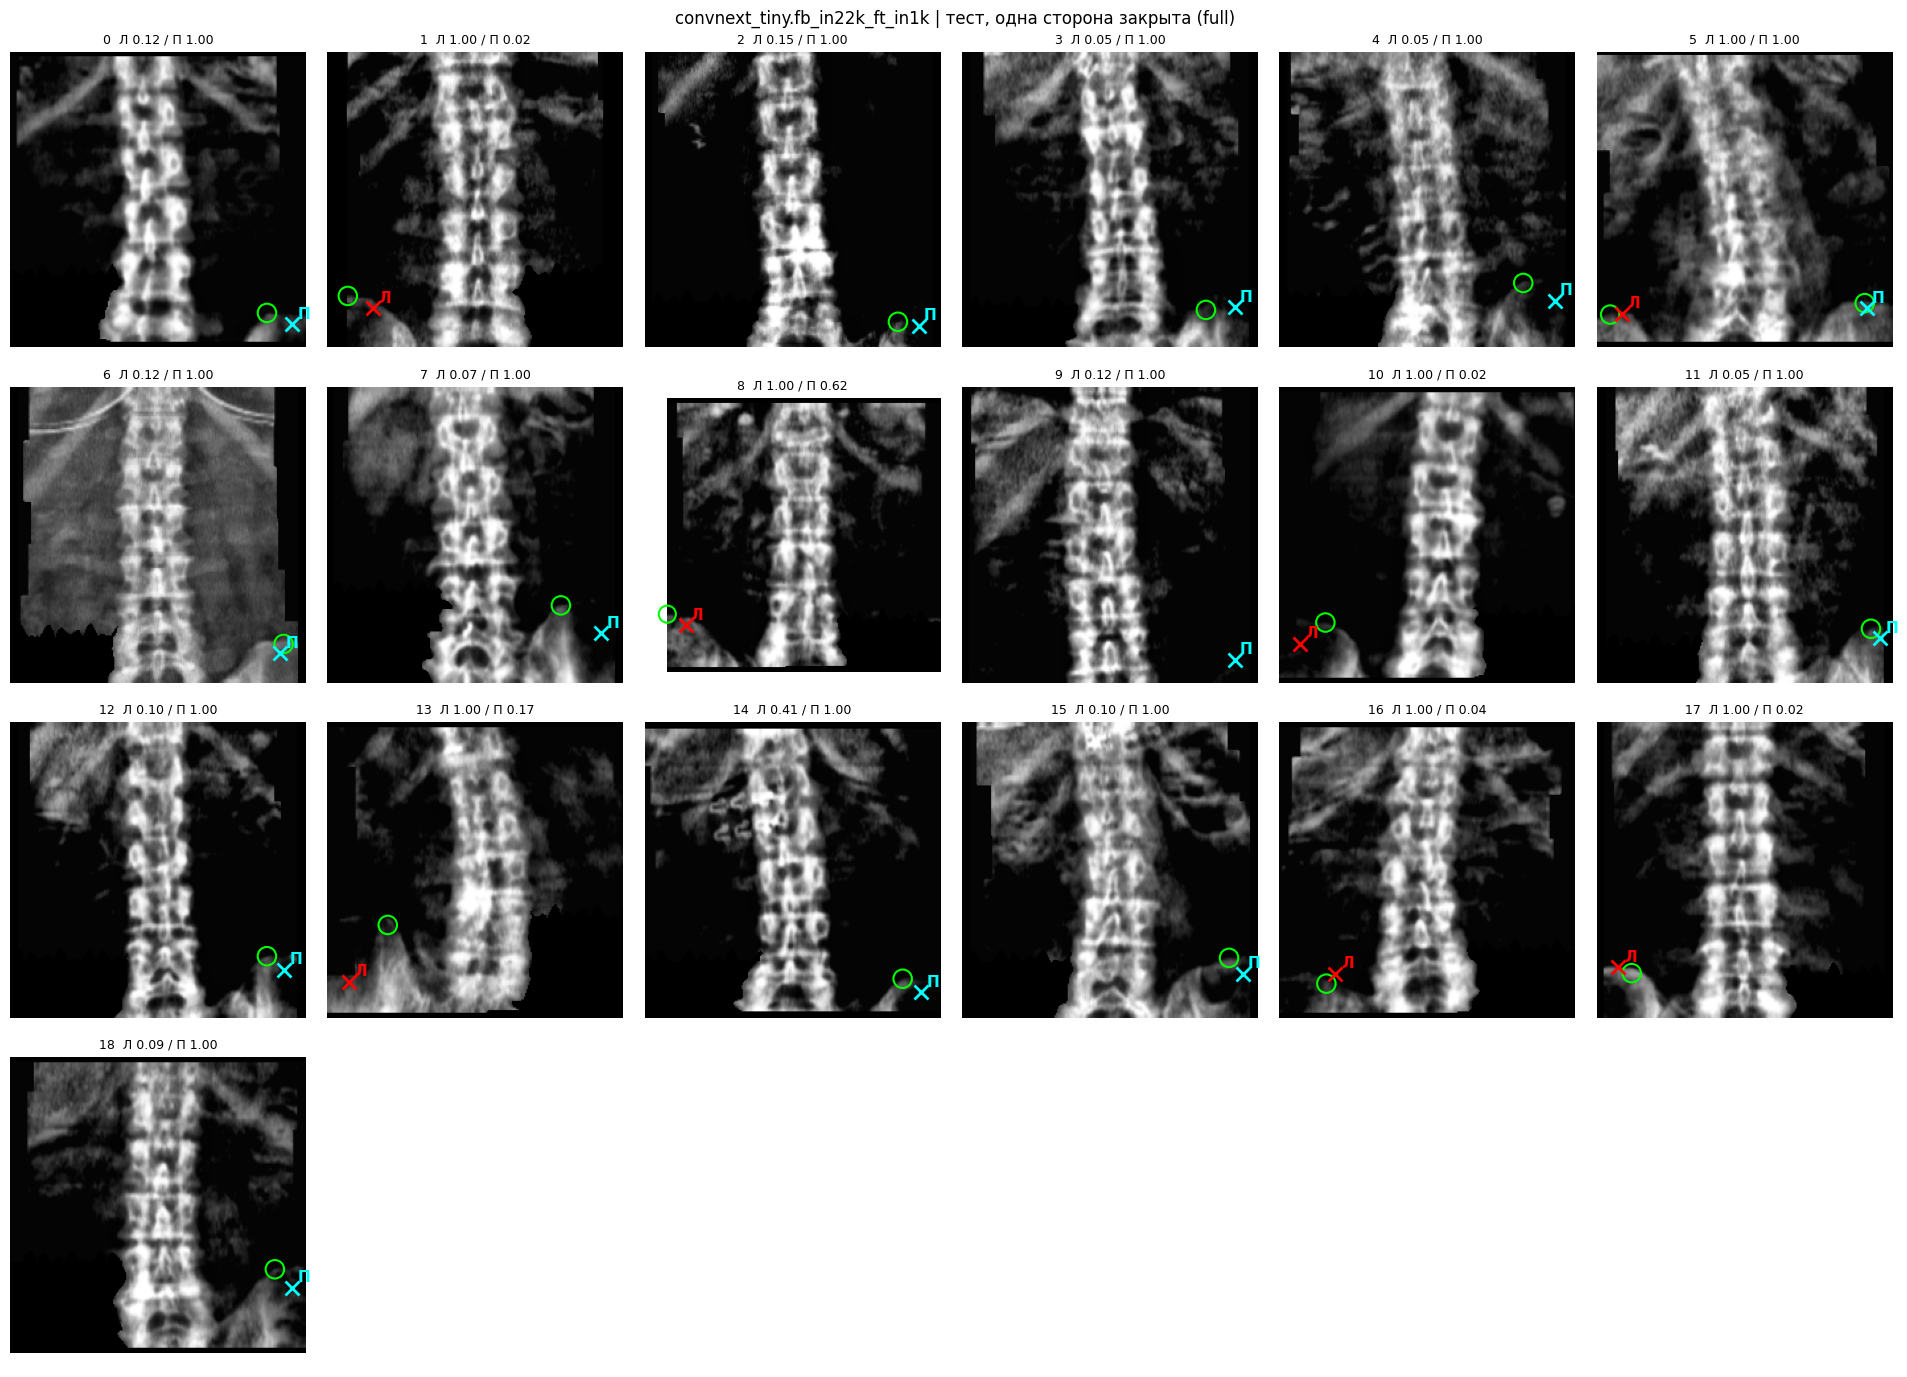

In [12]:
import matplotlib.pyplot as plt

SIDE_COLORS = ["red", "cyan"]  # левая / правая точка
SIDE_LETTERS = ["Л", "П"]


def show_test_predictions(df: pd.DataFrame, title: str, backbone_name: str, threshold: float, force_occlude: bool = False,
                          cols: int = 6, fname: str = None, show_below_threshold: bool = False):
    df_eval = force_occlude_all(df) if force_occlude else df
    ds = PelvisCrestDataset(df_eval, IMAGES_DIR, train=False, force_occlude_eval=force_occlude)
    model = load_model(backbone_name)
    n = len(ds)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for i in range(n):
        image, heatmaps, coords, visible = ds[i]
        with torch.no_grad():
            hm_logits, pres_logits = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(hm_logits)[0].cpu().numpy()
        pres = torch.sigmoid(pres_logits)[0].cpu().numpy()
        img = (image.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN)[..., 0]
        ax = axes[i]
        ax.imshow(np.clip(img, 0, 1), cmap="gray")
        for k in range(len(KEYPOINT_NAMES)):
            y, x = np.unravel_index(np.argmax(probs[k]), probs[k].shape)
            if visible[k] == 1:
                cx, cy = coords[k].tolist()
                ax.add_patch(plt.Circle((cx, cy), 7, fill=False, color="lime", linewidth=1.5))
            found = pres[k] >= threshold  # точка "есть" (0 или 1 крест на точку)
            if found or show_below_threshold:
                color = SIDE_COLORS[k] if found else "gray"
                ax.plot(x, y, "x", color=color, markersize=10, markeredgewidth=2)
                ax.text(x + 4, y - 4, SIDE_LETTERS[k], color=color, fontsize=11, fontweight="bold")
        ax.set_title(f"{i}  Л {pres[0]:.2f} / П {pres[1]:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    if fname:
        plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=110)
    plt.show()


for name in BACKBONE_CANDIDATES:
    thr = chosen_threshold[name]
    show_test_predictions(test_manifest, f"{name} | тест, естественные данные (порог {thr})", name, thr,
                          fname=f"test_{name}.png")
    random.seed(SEED)  # закрытая сторона выбирается случайно — фиксируем: у всех backbone одни и те же закрытые стороны
    show_test_predictions(test_manifest, f"{name} | тест, одна сторона закрыта (full)", name, thr, force_occlude=True,
                          fname=f"test_{name}_occluded.png")

# Часть 2. Классификатор «гребень в окне: да/нет»

Конфигурация классификатора (имена с префиксом `CLS_`, чтобы не пересекаться с keypoint-частью).

In [13]:
# --- классификатор + математика + голосование ---
# Окно: нижняя треть кадра и боковой угол; позвоночник в нём закрашивается по маске (CROP_MODE="spine").
CROP_TOP_FRAC = 0.667
SIDE_FRAC = 0.36
CROP_SIZE = 128
CROP_MODE = "spine"     # "spine": позвоночник внутри окна закрашен нулями построчно по маске столба; "rect": без закраски

CLS_BACKBONE_NAME = "convnext_tiny.fb_in22k_ft_in1k"
CLS_BATCH_SIZE = 16
CLS_NUM_EPOCHS = 15      # фиксированное число эпох, без ранней остановки
LR = 1e-4
WEIGHT_DECAY = 0.05
N_FOLDS = 5              # колонка fold из Step 1 (0..4)
SYNTH_NEG_PROB = 0.3     # доля положительных кропов, которые на лету становятся синтетическими негативами
SYNTH_FILL = "noise"     # "noise" (по умолчанию: на OOF отвергал 8 из 9 реальных негативов), "faint", "black" или "mix"
FAINT_P = 0.005
FAINT_AMP = 150
DECISION_THRESHOLD = 0.7 # классификатор: вероятность >= порога -> "гребень есть"

# математика: яркая кость у нижнего края окна
MATH_ROWS = 6            # сколько нижних строк окна смотрим
MATH_OUTER = 0.7         # какую внешнюю долю ширины окна (от края кадра) смотрим — подальше от позвоночника
MATH_REL = 0.15          # "ярко" = выше этой доли яркости кости на снимке (90-й перцентиль ненулевых пикселей)

VOTE_MIN = 2             # сколько методов из трёх должны сказать "есть"


def cls_worker_init_fn(worker_id: int) -> None:
    # seed воркера берётся из torch (меняется от эпохи к эпохе), иначе аугментации повторялись бы каждую эпоху
    worker_seed = torch.initial_seed() % (2 ** 32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

## Данные: кропы сторон и синтетические негативы

Метка стороны — «есть», если в манифесте у неё есть координата гребня. `synth_erase` стирает крыло от точки вниз и
наружу от позвоночника (граница у столба считается по строкам по маске столба — тот же приём, что и при проверке
аугментации закрытия в `train_pelvis_crest.ipynb`), заполняет шумом фона и размывает шов.

In [14]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

SIDES = ("left", "right")
CLS_COORD_COLS = {"left": ("greben_levo_x", "greben_levo_y"), "right": ("greben_pravo_x", "greben_pravo_y")}

SYNTH_EXCLUDE = {
    "1ab40e61b69ae442c6be051b7b9c1491.png": {"left"},
    "23eac28f7dd0f1c4a2459689b4a53da3.png": {"left", "right"},
    "26625c20719dd1284335ab516ae99971.png": {"right"},
    "29770d24bdf1f02106f04cc0f091f6d2.png": {"left"},
    "480855287efec4ed66e31f979cce396f.png": {"left", "right"},
    "408027217b49c3ca61b7e577918a8d44.png": {"left"},
    "582320894b66922860ac25310168527a.png": {"right"},
    "8680958a504686b8794854836c052b61.png": {"right"},
    "840dc40cb4fa67d575fc295921e081e2.png": {"left", "right"},
    "a3b07df372e1c69c07d2fd1efe793f1e.png": {"right"},
    "b293df24290f52a7837dd3268dae225a.png": {"right"},
    "b42fe6bdd2df1a8e2b6f2b619b1d1adf.png": {"left"},
    "bcf954d28b2217d780926ea310d4cf3d.png": {"right"},
    "be9577a5a6d08707bfb208c1d551a2a9.png": {"left", "right"},
    "c6aa8d320ec79c579f3ebb449c1e34e6.png": {"right"},
    "cdc320d488ad762459a12c7faedae0ec.png": {"right"},
    "ee986ce85c9f2e12222b072b6f081402.png": {"right"},
    "3f1a9b33e27d1d44f1af5051430c961d.png": {"left", "right"},
}


manifest = pd.read_csv(KEYPOINTS_MANIFEST_PATH)


def build_samples(df: pd.DataFrame) -> list:
    out = []
    for _, r in df.iterrows():
        for side in SIDES:
            xc, yc = CLS_COORD_COLS[side]
            present = not (pd.isna(r[xc]) or pd.isna(r[yc]))
            out.append({"image_filename": r["image_filename"], "side": side, "fold": int(r["fold"]),
                        "present": int(present),
                        "px": float(r[xc]) if present else None, "py": float(r[yc]) if present else None})
    return out


samples = build_samples(manifest)
n_pos = sum(s["present"] for s in samples)
print(f"сторон всего: {len(samples)}, гребень есть: {n_pos}, нет: {len(samples) - n_pos}")
assert sorted({s["fold"] for s in samples}) == list(range(N_FOLDS)), "ожидаются фолды 0..N_FOLDS-1"


def spine_mask(img: np.ndarray) -> np.ndarray:
    # маска столба на сыром снимке: порог от фона по краям кадра, компонента, содержащая центр по x
    sm = cv2.GaussianBlur(img.astype(np.float32), (0, 0), 1.5)
    h, w = img.shape
    cx0, cx1 = int(w * 0.25), int(w * 0.75)
    bg = np.percentile(sm[:, :int(w * 0.12)], 70) if w > 50 else 0
    col = sm[:, cx0:cx1]
    thr = bg + 0.5 * (np.percentile(col, 90) - bg)
    mask = (sm >= thr).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n <= 1:
        return mask.astype(bool)
    best, best_area = 0, 0
    for k in range(1, n):
        x, y, bw, bh, area = stats[k]
        if x <= w // 2 <= x + bw and area > best_area:
            best, best_area = k, area
    return labels == best


def spine_edges(img: np.ndarray, margin: int = 9):  # запас 9 px: свечение края столба шире порога маски
    # для каждой строки: левый и правый край столба (+запас); пропущенные строки берут соседние;
    # границы зажаты, чтобы крыло, слившееся со столбом внизу, не считалось столбом
    h, w = img.shape
    sp = spine_mask(img)
    left = np.full(h, np.nan)
    right = np.full(h, np.nan)
    for y in range(h):
        xs = np.where(sp[y])[0]
        if len(xs):
            left[y] = xs.min() - margin
            right[y] = xs.max() + 1 + margin
    left = pd.Series(left).ffill().bfill().to_numpy()
    right = pd.Series(right).ffill().bfill().to_numpy()
    if np.isnan(left).any():
        left[:], right[:] = 0.36 * w, 0.64 * w
    return np.clip(left, 0.28 * w, 0.5 * w), np.clip(right, 0.5 * w, 0.72 * w)


def synth_erase(img: np.ndarray, side: str, px: float, py: float, edges=None) -> np.ndarray:
    # стираем крыло: от точки вниз, наружу от столба; шум фона вместо нулей, волнистый верхний край, размытый шов
    h, w = img.shape
    left_e, right_e = edges if edges is not None else spine_edges(img)
    phase = random.uniform(0, 30)
    mask = np.zeros((h, w), np.float32)
    y_start = max(0, int(py) - 6 - 12)
    for y in range(y_start, h):
        xs = np.arange(0, int(left_e[y])) if side == "left" else np.arange(int(right_e[y]), w)
        if len(xs) == 0:
            continue
        jitter = np.abs(6 * np.sin(0.18 * (xs + phase)) + 4 * np.sin(0.41 * (xs + phase) + 1.3))
        mask[y, xs] = (y >= int(py) - 6 - jitter).astype(np.float32)
    alpha = np.clip(cv2.GaussianBlur(mask, (0, 0), 2.0), 0, 1)
    mode = random.choice(["noise", "black"]) if SYNTH_FILL == "mix" else SYNTH_FILL
    if mode == "black":
        fill = np.zeros((h, w), np.float32)
    elif mode == "faint":
        # реальный пустой фон на этих снимках: ~98% пикселей ровно 0, изредка слабые значения — гауссов шум был бы заметно
        # "грязнее" и стал бы приметой синтетики
        sparse = (np.random.rand(h, w) < FAINT_P) * np.random.uniform(1, FAINT_AMP, (h, w))
        fill = cv2.GaussianBlur(sparse.astype(np.float32), (0, 0), 1.0)
    else:
        dark = img[img <= np.percentile(img, 35)].astype(np.float32)
        mu, sd = float(dark.mean()), max(float(dark.std()), 2.0)
        fill = cv2.GaussianBlur(np.random.normal(mu, sd * 3.0, (h, w)).astype(np.float32), (0, 0), 1.5)
    out = img.astype(np.float32) * (1 - alpha) + np.clip(fill, 0, 255) * alpha
    return np.clip(out, 0, 255).astype(np.uint8)


def crop_window(img: np.ndarray, side: str, edges=None):
    # окно в координатах исходного кадра: (x0, x1, y0) — нижняя треть, боковой угол шириной SIDE_FRAC
    h, w = img.shape
    y0, wx = int(CROP_TOP_FRAC * h), int(SIDE_FRAC * w)
    return (0, wx, y0) if side == "left" else (w - wx, w, y0)


def masked_window(img: np.ndarray, side: str, edges=None) -> np.ndarray:
    # Окно, повёрнутое так, что внешний край кадра слева, а позвоночник справа. При CROP_MODE == "spine" пиксели позвоночника
    # (построчно, по маске столба + запас) зануляются: даже если позвоночник искривлён и заходит в окно, он закрашен маской.
    x0, x1, y0 = crop_window(img, side)
    win = img[y0:, x0:x1].copy()
    if CROP_MODE == "spine":
        left_e, right_e = edges if edges is not None else spine_edges(img)
        rows = np.arange(y0, img.shape[0])
        cols = np.arange(win.shape[1])[None, :]
        if side == "left":
            cut = np.clip(left_e[rows].astype(int) - x0, 0, win.shape[1])    # столбцы >= cut — позвоночник
            win[cols >= cut[:, None]] = 0
        else:
            cut = np.clip(right_e[rows].astype(int) - x0, 0, win.shape[1])   # столбцы < cut — позвоночник
            win[cols < cut[:, None]] = 0
    return win if side == "left" else win[:, ::-1]


def crop_side(img: np.ndarray, side: str, edges=None) -> np.ndarray:
    win = masked_window(img, side, edges)
    return cv2.resize(np.ascontiguousarray(win), (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_AREA)


def augment(crop: np.ndarray) -> np.ndarray:
    c = crop.astype(np.float32)
    if random.random() < 0.8:
        c = c * random.uniform(0.75, 1.25) + random.uniform(-25, 25)
    c = np.clip(c, 0, 255)
    if random.random() < 0.5:
        c = 255.0 * (c / 255.0) ** random.uniform(0.7, 1.3)
    if random.random() < 0.4:
        c = c + np.random.normal(0, random.uniform(5, 15), c.shape)
    if random.random() < 0.7:
        M = cv2.getRotationMatrix2D((CROP_SIZE / 2, CROP_SIZE / 2), random.uniform(-10, 10), random.uniform(0.9, 1.1))
        M[:, 2] += np.random.uniform(-0.06, 0.06, 2) * CROP_SIZE
        c = cv2.warpAffine(c, M, (CROP_SIZE, CROP_SIZE), borderMode=cv2.BORDER_REPLICATE)
    return np.clip(c, 0, 255).astype(np.uint8)


def to_tensor(crop: np.ndarray) -> torch.Tensor:
    rgb = (np.stack([crop] * 3, axis=-1).astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(rgb.transpose(2, 0, 1)).float()


def can_synth(s: dict) -> bool:
    return s["present"] == 1 and s["side"] not in SYNTH_EXCLUDE.get(s["image_filename"], set())


class SideDataset(Dataset):
    # train=True: аугментации + случайные синтетические негативы (SYNTH_NEG_PROB);
    # force_synth=True: ВСЕ положительные (кроме исключений) становятся синтетическими негативами, детерминированно (для оценки)
    def __init__(self, samples: list, images_dir: str, train: bool, force_synth: bool = False):
        self.samples, self.images_dir, self.train, self.force_synth = samples, images_dir, train, force_synth

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = cv2.imread(os.path.join(self.images_dir, s["image_filename"]), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(s["image_filename"])
        edges = spine_edges(img)  # по исходному снимку (до стирания)
        label, synth = s["present"], 0
        if can_synth(s) and (self.force_synth or (self.train and random.random() < SYNTH_NEG_PROB)):
            if self.force_synth:
                random.seed(idx)
                np.random.seed(idx)
            img = synth_erase(img, s["side"], s["px"], s["py"], edges)
            label, synth = 0, 1
        crop = crop_side(img, s["side"], edges)
        if self.train:
            crop = augment(crop)
        return to_tensor(crop), torch.tensor(float(label)), torch.tensor(synth)

сторон всего: 198, гребень есть: 189, нет: 9


## Модель

In [15]:
def make_model() -> nn.Module:
    return timm.create_model(CLS_BACKBONE_NAME, pretrained=PRETRAINED_BACKBONE, num_classes=1)  # один логит: гребень есть


def predict_probs(model: nn.Module, ds: Dataset) -> np.ndarray:
    model.eval()
    loader = DataLoader(ds, batch_size=CLS_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    out = []
    with torch.no_grad():
        for x, y, synth in loader:
            out.append(torch.sigmoid(model(x.to(DEVICE)).squeeze(1)).cpu().numpy())
    return np.concatenate(out)


def cls_train_model(train_samples: list, seed: int) -> nn.Module:
    set_full_determinism(seed)
    ds = SideDataset(train_samples, IMAGES_DIR, train=True)
    loader = DataLoader(ds, batch_size=CLS_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True,
                        worker_init_fn=cls_worker_init_fn, generator=make_generator(seed))
    model = make_model().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CLS_NUM_EPOCHS)
    for epoch in range(CLS_NUM_EPOCHS):
        model.train()
        total, correct, n = 0.0, 0, 0
        for x, y, synth in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x).squeeze(1)
            loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
            correct += int(((logits > 0).float() == y).sum().item())
            n += x.size(0)
        sched.step()
        print(f"  epoch {epoch + 1}/{CLS_NUM_EPOCHS} | loss={total / n:.4f} acc={correct / n:.3f}")
    return model

## Кросс-валидация (оценка качества)

Для каждого фолда: обучение на остальных, предсказание на отложенном — на **естественных** сторонах и на
**синтетических негативах** (все положительные стороны этого фолда со стёртым крылом). Число эпох фиксировано, отложенный фолд
в выборе эпохи не участвует. Модели фолдов **не сохраняются** и в прод не идут — в прод идёт финальная модель ниже.

In [16]:
oof_rows, synth_rows = [], []
for fold in range(N_FOLDS):
    print(f"\n===== фолд {fold} (отложен) =====")
    train_s = [s for s in samples if s["fold"] != fold]
    val_s = [s for s in samples if s["fold"] == fold]
    model = cls_train_model(train_s, SEED + fold)

    probs = predict_probs(model, SideDataset(val_s, IMAGES_DIR, train=False))
    for s, p in zip(val_s, probs):
        oof_rows.append({"image_filename": s["image_filename"], "side": s["side"], "fold": fold, "present": s["present"], "prob": float(p)})

    val_syn = [s for s in val_s if can_synth(s)]
    probs_syn = predict_probs(model, SideDataset(val_syn, IMAGES_DIR, train=False, force_synth=True))
    for s, p in zip(val_syn, probs_syn):
        synth_rows.append({"image_filename": s["image_filename"], "side": s["side"], "fold": fold, "prob": float(p)})
    del model

oof_df = pd.DataFrame(oof_rows)
synth_df = pd.DataFrame(synth_rows)
oof_df.to_csv(os.path.join(OUTPUT_DIR, "oof_natural.csv"), index=False)
synth_df.to_csv(os.path.join(OUTPUT_DIR, "oof_synthetic.csv"), index=False)
print("\nOOF готово: естественных сторон", len(oof_df), "| синтетических негативов", len(synth_df))


===== фолд 0 (отложен) =====
  epoch 1/15 | loss=0.3877 acc=0.819
  epoch 2/15 | loss=0.0559 acc=0.993
  epoch 3/15 | loss=0.0260 acc=0.993
  epoch 4/15 | loss=0.0081 acc=1.000
  epoch 5/15 | loss=0.0028 acc=1.000
  epoch 6/15 | loss=0.1297 acc=0.958
  epoch 7/15 | loss=0.0236 acc=1.000
  epoch 8/15 | loss=0.0211 acc=0.993
  epoch 9/15 | loss=0.0102 acc=1.000
  epoch 10/15 | loss=0.0392 acc=0.986
  epoch 11/15 | loss=0.0246 acc=0.993
  epoch 12/15 | loss=0.0053 acc=1.000
  epoch 13/15 | loss=0.0025 acc=1.000
  epoch 14/15 | loss=0.0024 acc=1.000
  epoch 15/15 | loss=0.0052 acc=1.000

===== фолд 1 (отложен) =====
  epoch 1/15 | loss=0.2605 acc=0.917
  epoch 2/15 | loss=0.0523 acc=0.979
  epoch 3/15 | loss=0.0572 acc=0.972
  epoch 4/15 | loss=0.0305 acc=0.993
  epoch 5/15 | loss=0.0060 acc=1.000
  epoch 6/15 | loss=0.0020 acc=1.000
  epoch 7/15 | loss=0.0476 acc=0.986
  epoch 8/15 | loss=0.0396 acc=0.993
  epoch 9/15 | loss=0.0098 acc=1.000
  epoch 10/15 | loss=0.0152 acc=0.993
  epoch 

## Оценка (OOF, все фолды вместе)

- **Реальные негативы** — 9 сторон, где гребня в кадре нет по разметке: главное число для «не ставить точку зря».
- **Синтетические негативы** — те же положительные стороны со стёртым крылом: проверка, что классификатор вообще видит
  разницу; на реальные негативы это переносится не гарантированно, поэтому реальные считаем отдельно.
- Порог не подбирается автоматически: смотрите таблицу и выбирайте `DECISION_THRESHOLD`.

In [17]:
CLS_THRESHOLDS = (0.1, 0.3, 0.5, 0.7, 0.9)

y, p = oof_df["present"].to_numpy(), oof_df["prob"].to_numpy()
p_syn = synth_df["prob"].to_numpy()
n_real_neg = int((y == 0).sum())

print(f"Естественные стороны (OOF): {len(y)}, гребень есть {int(y.sum())}, нет {n_real_neg}")
if n_real_neg:
    print(f"  AUC (есть vs реальные «нет»): {roc_auc_score(y, p):.3f}")
print(f"  AUC (есть vs синтетические «нет»): {roc_auc_score(np.r_[np.ones(int(y.sum())), np.zeros(len(p_syn))], np.r_[p[y == 1], p_syn]):.3f}")
print()
print("  порог | гребни найдены | потеряно | реальных «нет» отвергнуто | ложных точек | синтетич. «нет» отвергнуто")
for thr in CLS_THRESHOLDS:
    found = (p[y == 1] >= thr).mean()
    lost = int((p[y == 1] < thr).sum())
    rej = (p[y == 0] < thr).mean() if n_real_neg else float("nan")
    fp = int((p[y == 0] >= thr).sum())
    rej_syn = (p_syn < thr).mean()
    print(f"  {thr:5.2f} | {found:14.3f} | {lost:8d} | {rej:6.3f} (из {n_real_neg}) | {fp:12d} | {rej_syn:.3f}")

print(f"\nОшибки при DECISION_THRESHOLD={DECISION_THRESHOLD} (естественные стороны):")
err = oof_df[((oof_df["present"] == 1) & (oof_df["prob"] < DECISION_THRESHOLD)) |
             ((oof_df["present"] == 0) & (oof_df["prob"] >= DECISION_THRESHOLD))].sort_values("prob")
print(err.round(3).to_string(index=False) if len(err) else "нет")

Естественные стороны (OOF): 198, гребень есть 189, нет 9
  AUC (есть vs реальные «нет»): 0.999
  AUC (есть vs синтетические «нет»): 1.000

  порог | гребни найдены | потеряно | реальных «нет» отвергнуто | ложных точек | синтетич. «нет» отвергнуто
   0.10 |          1.000 |        0 |  0.778 (из 9) |            2 | 1.000
   0.30 |          1.000 |        0 |  0.778 (из 9) |            2 | 1.000
   0.50 |          1.000 |        0 |  0.778 (из 9) |            2 | 1.000
   0.70 |          1.000 |        0 |  0.778 (из 9) |            2 | 1.000
   0.90 |          1.000 |        0 |  0.778 (из 9) |            2 | 1.000

Ошибки при DECISION_THRESHOLD=0.7 (естественные стороны):
                      image_filename  side  fold  present  prob
816f11f96993995edea103b3468a3292.png right     1        0 0.954
451974b98bd3ce3fec02cf0042aafe41.png right     0        0 0.988


## Финальная модель (для прода)

Одна модель, обученная на **всех** размеченных сторонах (тот же рецепт и то же число эпох, что оценивались выше).
Сохраняется в `pelvis_presence.pt` вместе с настройками окна. Это единственный файл, который нужен в проде.

In [18]:
CLS_CKPT = os.path.join(OUTPUT_DIR, "pelvis_presence.pt")

print(f"Финальная модель: обучение на всех {len(samples)} сторонах, {CLS_NUM_EPOCHS} эпох")
cls_model = cls_train_model(samples, SEED)
torch.save({"model_state_dict": cls_model.state_dict(), "backbone_name": CLS_BACKBONE_NAME,
            "config": {"CROP_TOP_FRAC": CROP_TOP_FRAC, "SIDE_FRAC": SIDE_FRAC, "CROP_SIZE": CROP_SIZE, "CROP_MODE": CROP_MODE}},
           CLS_CKPT)
print("сохранено:", CLS_CKPT)

Финальная модель: обучение на всех 198 сторонах, 15 эпох
  epoch 1/15 | loss=0.2047 acc=0.932
  epoch 2/15 | loss=0.1526 acc=0.958
  epoch 3/15 | loss=0.0692 acc=0.990
  epoch 4/15 | loss=0.0525 acc=0.984
  epoch 5/15 | loss=0.0455 acc=0.990
  epoch 6/15 | loss=0.0089 acc=1.000
  epoch 7/15 | loss=0.0102 acc=0.995
  epoch 8/15 | loss=0.0294 acc=0.990
  epoch 9/15 | loss=0.0075 acc=1.000
  epoch 10/15 | loss=0.0048 acc=1.000
  epoch 11/15 | loss=0.0222 acc=0.995
  epoch 12/15 | loss=0.0030 acc=1.000
  epoch 13/15 | loss=0.0015 acc=1.000
  epoch 14/15 | loss=0.0259 acc=0.990
  epoch 15/15 | loss=0.0021 acc=1.000
сохранено: ./outputs_pelvis_crest/pelvis_presence.pt


## Прогон на исходных снимках: решение «ставить точку / не ставить»

`cls_predict_sides` берёт снимок целиком, вырезает оба угла и возвращает вероятность гребня для каждой стороны;
`place_left / place_right = True` — точку ставить. Здесь работает финальная модель. Оценка на размеченных снимках
**оптимистична** (модель их видела при обучении) — для честной оценки смотрите OOF-таблицу выше. `cls_run_on_images` — то, что
вызывается для новых снимков.

In [19]:
def load_cls_model(path: str = CLS_CKPT) -> nn.Module:
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    m = timm.create_model(ck["backbone_name"], pretrained=False, num_classes=1).to(DEVICE)
    m.load_state_dict(ck["model_state_dict"])
    m.eval()
    return m


def cls_predict_sides(model: nn.Module, img_gray: np.ndarray) -> dict:
    # вероятность гребня для каждой стороны
    out = {}
    edges = spine_edges(img_gray)
    for side in SIDES:
        x = to_tensor(crop_side(img_gray, side, edges)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out[side] = float(torch.sigmoid(model(x)).item())
    return out


def cls_run_on_images(model: nn.Module, filenames: list, images_dir: str = IMAGES_DIR, threshold: float = None) -> pd.DataFrame:
    threshold = DECISION_THRESHOLD if threshold is None else threshold
    rows = []
    for f in filenames:
        img = cv2.imread(os.path.join(images_dir, f), cv2.IMREAD_GRAYSCALE)
        pr = cls_predict_sides(model, img)
        rows.append({"image_filename": f, "p_left": pr["left"], "p_right": pr["right"],
                     "place_left": pr["left"] >= threshold, "place_right": pr["right"] >= threshold})
    return pd.DataFrame(rows)


def attach_gt(df: pd.DataFrame) -> pd.DataFrame:
    gt = pd.DataFrame(samples).pivot(index="image_filename", columns="side", values="present").rename(columns={"left": "gt_left", "right": "gt_right"})
    out = df.merge(gt.reset_index(), on="image_filename")
    out["ok"] = (out["place_left"] == out["gt_left"].astype(bool)) & (out["place_right"] == out["gt_right"].astype(bool))
    return out


cls_model = load_cls_model()
cls_final_df = attach_gt(cls_run_on_images(cls_model, list(manifest["image_filename"])))
cls_final_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "pelvis_presence_final.csv"), index=False)
print(f"финальная модель на исходных снимках: {len(cls_final_df)} снимков, ошибок решения {int((~cls_final_df['ok']).sum())} (оптимистично: снимки обучающие)")

oof_wide = oof_df.pivot(index="image_filename", columns="side", values="prob").rename(columns={"left": "p_left", "right": "p_right"}).reset_index()
oof_wide["place_left"] = oof_wide["p_left"] >= DECISION_THRESHOLD
oof_wide["place_right"] = oof_wide["p_right"] >= DECISION_THRESHOLD
oof_wide = attach_gt(oof_wide)
oof_wide.round(4).to_csv(os.path.join(OUTPUT_DIR, "pelvis_presence_oof.csv"), index=False)
print(f"OOF (честная оценка): решение верно по обеим сторонам на {int(oof_wide['ok'].sum())} из {len(oof_wide)} снимков")
print(oof_wide[~oof_wide["ok"]].round(3).to_string(index=False))

финальная модель на исходных снимках: 99 снимков, ошибок решения 0 (оптимистично: снимки обучающие)
OOF (честная оценка): решение верно по обеим сторонам на 97 из 99 снимков
                      image_filename  p_left  p_right  place_left  place_right  gt_left  gt_right    ok
451974b98bd3ce3fec02cf0042aafe41.png   0.998    0.988        True         True        1         0 False
816f11f96993995edea103b3468a3292.png   0.004    0.954       False         True        0         0 False


# Часть 3. Математика: есть ли яркая кость у нижнего края окна

Признак — доля «ярких» пикселей (выше `MATH_REL` × яркость кости на снимке) в нижних `MATH_ROWS` строках окна, только во внешних `MATH_OUTER` его ширины
(чем дальше от позвоночника, тем надёжнее; сам позвоночник уже закрашен маской). Физический смысл: крыло подвздошной кости, если оно в кадре,
всегда уходит к нижнему краю снимка. Без обучения; порог — середина зазора между самым ярким «нет» и самым слабым «есть» (среднее геометрическое).
Функция возвращает **сам признак**, поэтому видно, насколько уверенно решение.

In [20]:
def math_score(img: np.ndarray, side: str, edges=None) -> float:
    win = masked_window(img, side, edges).astype(np.float32)  # внешний край кадра слева, позвоночник справа и закрашен
    sm = cv2.GaussianBlur(win, (0, 0), 1.5)
    ref = float(np.percentile(img[img > 0], 90)) if (img > 0).any() else 1.0
    bot = sm[-MATH_ROWS:, : int(MATH_OUTER * sm.shape[1])] > MATH_REL * ref
    return float(bot.mean())


def build_math_table(sample_list: list) -> pd.DataFrame:
    rows, by_img = [], {}
    for s in sample_list:
        by_img.setdefault(s["image_filename"], []).append(s)
    for f, ss in by_img.items():
        img = cv2.imread(os.path.join(IMAGES_DIR, f), cv2.IMREAD_GRAYSCALE)
        edges = spine_edges(img)
        for s in ss:
            rows.append({"image_filename": f, "side": s["side"], "fold": s["fold"], "truth": s["present"],
                         "score": math_score(img, s["side"], edges)})
    return pd.DataFrame(rows)


def fit_math_threshold(tbl: pd.DataFrame) -> float:
    pos, neg = tbl[tbl.truth == 1]["score"], tbl[tbl.truth == 0]["score"]
    lo, hi = (float(neg.max()) if len(neg) else 0.0), float(pos.min())
    return float(np.sqrt(max(lo, 1e-4) * hi)) if hi > lo else (lo + hi) / 2


math_table = build_math_table(samples)
MATH_T_ALL = fit_math_threshold(math_table)
pos_s, neg_s = math_table[math_table.truth == 1]["score"], math_table[math_table.truth == 0]["score"]
print(f"Математика на всех сторонах: AUC {roc_auc_score(math_table.truth, math_table.score):.3f}")
print(f"  у «есть»: мин {pos_s.min():.3f}, медиана {pos_s.median():.3f} | у «нет»: макс {neg_s.max():.3f}, медиана {neg_s.median():.3f}")
print(f"  порог (середина зазора) = {MATH_T_ALL:.4f}")

# честная оценка: порог подбирается без проверяемого снимка (leave-one-image-out)
lost, false_pos = [], []
for f in math_table.image_filename.unique():
    tr, te = math_table[math_table.image_filename != f], math_table[math_table.image_filename == f]
    t = fit_math_threshold(tr)
    for _, r in te.iterrows():
        if r.truth == 1 and r.score < t:
            lost.append((f[:8], r.side, round(r.score, 3), round(t, 3)))
        if r.truth == 0 and r.score >= t:
            false_pos.append((f[:8], r.side, round(r.score, 3), round(t, 3)))
print(f"leave-one-image-out: потеряно гребней {len(lost)}/{int(pos_s.size)}, ложных точек {len(false_pos)}/{int(neg_s.size)}")
for x in lost + false_pos:
    print("  ошибка:", x)

Математика на всех сторонах: AUC 1.000
  у «есть»: мин 0.091, медиана 0.680 | у «нет»: макс 0.038, медиана 0.000
  порог (середина зазора) = 0.0587
leave-one-image-out: потеряно гребней 0/189, ложных точек 1/9
  ошибка: ('451974b9', 'right', 0.038, 0.003)


# Часть 4. Голосование трёх методов

Для каждой стороны: `keypoint` (вероятность присутствия ≥ порога из калибровки keypoint-части), `classifier` (вероятность ≥ `DECISION_THRESHOLD`),
`math` (признак ≥ порога). Решение — минимум `VOTE_MIN` голосов «есть».

In [21]:
KP_NAME = BACKBONE_CANDIDATES[0]
kp_model = load_model(KP_NAME)
KP_THR = chosen_threshold[KP_NAME]
print(f"keypoint: {KP_NAME}, порог присутствия {KP_THR}")


def keypoint_side_probs(model, df: pd.DataFrame) -> np.ndarray:
    # (n, 2): вероятность присутствия левой/правой точки для строк df в том же порядке
    tv, sc, er = collect_predictions(model, df)
    return sc.reshape(-1, 2)


def vote_table(folds: list, math_thr: float) -> pd.DataFrame:
    df = manifest[manifest["fold"].isin(folds)].reset_index(drop=True)
    kp = keypoint_side_probs(kp_model, df)
    oof = oof_df.pivot(index="image_filename", columns="side", values="prob")
    mt = math_table.set_index(["image_filename", "side"])["score"]
    rows = []
    for i, r in df.iterrows():
        for k, side in enumerate(SIDES):
            gt = int(pd.notna(r[CLS_COORD_COLS[side][0]]))
            v = {"keypoint": bool(kp[i, k] >= KP_THR), "classifier": bool(oof.loc[r.image_filename, side] >= DECISION_THRESHOLD),
                 "math": bool(mt[(r.image_filename, side)] >= math_thr)}
            rows.append({"image_filename": r.image_filename, "side": side, "fold": int(r.fold), "truth": gt, **v,
                         "vote": sum(v.values()) >= VOTE_MIN})
    return pd.DataFrame(rows)


def summarize(t: pd.DataFrame, title: str) -> None:
    n_pos, n_neg = int((t.truth == 1).sum()), int((t.truth == 0).sum())
    print(f"{title}: сторон {len(t)} (гребень есть {n_pos}, нет {n_neg})")
    print("  метод        | гребни найдены | потеряно | «нет» отвергнуто | ложных точек")
    for m in ("keypoint", "classifier", "math", "vote"):
        found = int(((t[m]) & (t.truth == 1)).sum())
        fp = int(((t[m]) & (t.truth == 0)).sum())
        print(f"  {m:12s} | {found:4d} / {n_pos:<4d}    | {n_pos - found:8d} | {n_neg - fp:5d} / {n_neg:<5d}    | {fp:8d}")


for folds, title in (([TEST_FOLD], "ТЕСТ (отложенный фолд)"), ([VAL_FOLD, TEST_FOLD], "ВАЛИДАЦИЯ + ТЕСТ (keypoint: порог/эпоха выбраны по валидации — чуть оптимистично)")):
    math_thr_fold = fit_math_threshold(math_table[~math_table.fold.isin(folds)])   # порог математики — без проверяемых фолдов
    t = vote_table(folds, math_thr_fold)
    summarize(t, title)
    bad = t[(t.vote != t.truth.astype(bool)) | (t[["keypoint", "classifier", "math"]].nunique(axis=1) > 1)]
    if len(bad):
        print("  спорные / ошибочные стороны (гт = есть ли гребень):")
        print(bad[["image_filename", "side", "truth", "keypoint", "classifier", "math", "vote"]].to_string(index=False))
    print()

keypoint: convnext_tiny.fb_in22k_ft_in1k, порог присутствия 0.97
ТЕСТ (отложенный фолд): сторон 38 (гребень есть 36, нет 2)
  метод        | гребни найдены | потеряно | «нет» отвергнуто | ложных точек
  keypoint     |   36 / 36      |        0 |     1 / 2        |        1
  classifier   |   36 / 36      |        0 |     2 / 2        |        0
  math         |   36 / 36      |        0 |     2 / 2        |        0
  vote         |   36 / 36      |        0 |     2 / 2        |        0
  спорные / ошибочные стороны (гт = есть ли гребень):
                      image_filename  side  truth  keypoint  classifier  math  vote
60d23bf9bbd4afc9ca1c7a64e71c6201.png right      0      True       False False False

ВАЛИДАЦИЯ + ТЕСТ (keypoint: порог/эпоха выбраны по валидации — чуть оптимистично): сторон 78 (гребень есть 72, нет 6)
  метод        | гребни найдены | потеряно | «нет» отвергнуто | ложных точек
  keypoint     |   72 / 72      |        0 |     4 / 6        |        2
  classifier   |

## Итоговая функция и прогон на исходных снимках

`decide_sides(img)` берёт снимок целиком и возвращает по каждой стороне голоса трёх методов, решение и — если решение «есть» — **координату точки
в исходных пикселях снимка** (её даёт keypoint-модель). Оценка на размеченных снимках оптимистична (финальные модели их видели);
честные цифры — в таблицах выше.

In [22]:
cls_model = load_cls_model()
MATH_THR_FINAL = MATH_T_ALL


def keypoint_infer(model, img: np.ndarray) -> dict:
    # вероятность присутствия и координата пика heatmap в ИСХОДНЫХ пикселях для каждой стороны
    h, w = img.shape
    out = build_eval_transform()(image=clahe(img), keypoints=[(0.0, 0.0), (float(w), float(h))])
    im, (p0, p1) = out["image"], out["keypoints"]
    sx, sy = (p1[0] - p0[0]) / w, (p1[1] - p0[1]) / h  # обратное преобразование считаем по образам двух известных точек
    rgb = (np.stack([im] * 3, axis=-1).astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(rgb.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        hm_logits, pres_logits = model(x)
    hm = torch.sigmoid(hm_logits)[0].cpu().numpy()
    pres = torch.sigmoid(pres_logits)[0].cpu().numpy()
    res = {}
    for k, side in enumerate(SIDES):
        yy, xx = np.unravel_index(np.argmax(hm[k]), hm[k].shape)
        res[side] = (float(pres[k]), ((float(xx) - p0[0]) / sx, (float(yy) - p0[1]) / sy))
    return res


def decide_sides(img: np.ndarray) -> dict:
    edges = spine_edges(img)
    kp = keypoint_infer(kp_model, img)
    cl = cls_predict_sides(cls_model, img)
    out = {}
    for side in SIDES:
        votes = {"keypoint": kp[side][0] >= KP_THR, "classifier": cl[side] >= DECISION_THRESHOLD,
                 "math": math_score(img, side, edges) >= MATH_THR_FINAL}
        present = sum(votes.values()) >= VOTE_MIN
        out[side] = {"present": present, "votes": votes, "point": kp[side][1] if present else None,
                     "p_keypoint": kp[side][0], "p_classifier": cl[side]}
    return out


# sanity: обратное преобразование координат точно возвращает размеченную точку (проверка на нескольких снимках)
_chk = manifest.dropna(subset=["greben_levo_x"]).head(5)
_errs = []
for _, r in _chk.iterrows():
    im0 = cv2.imread(os.path.join(IMAGES_DIR, r["image_filename"]), cv2.IMREAD_GRAYSCALE)
    h0, w0 = im0.shape
    o = build_eval_transform()(image=clahe(im0), keypoints=[(0.0, 0.0), (float(w0), float(h0)), (r["greben_levo_x"], r["greben_levo_y"])])["keypoints"]
    _sx, _sy = (o[1][0] - o[0][0]) / w0, (o[1][1] - o[0][1]) / h0
    _errs.append(max(abs((o[2][0] - o[0][0]) / _sx - r["greben_levo_x"]), abs((o[2][1] - o[0][1]) / _sy - r["greben_levo_y"])))
print(f"обратное преобразование координат: макс. ошибка {max(_errs):.4f} px")

rows = []
for _, r in manifest.iterrows():
    img = cv2.imread(os.path.join(IMAGES_DIR, r["image_filename"]), cv2.IMREAD_GRAYSCALE)
    d = decide_sides(img)
    for side in SIDES:
        gx, gy = CLS_COORD_COLS[side]
        gt = int(pd.notna(r[gx]))
        px, py = d[side]["point"] if d[side]["point"] else (np.nan, np.nan)
        err = float(np.hypot(px - r[gx], py - r[gy])) if (gt and d[side]["present"]) else np.nan
        rows.append({"image_filename": r["image_filename"], "side": side, "fold": int(r["fold"]), "truth": gt, **d[side]["votes"],
                     "vote": d[side]["present"], "p_keypoint": d[side]["p_keypoint"], "p_classifier": d[side]["p_classifier"],
                     "x": px, "y": py, "point_err_px": err})
vote_df = pd.DataFrame(rows)
vote_df.round(4).to_csv(os.path.join(OUTPUT_DIR, "pelvis_vote_all.csv"), index=False)
print("записано pelvis_vote_all.csv:", len(vote_df), "сторон")
summarize(vote_df, "ВСЕ размеченные снимки (оптимистично: финальные модели их видели)")
print(f"ошибка точки (там, где решено «есть» и гребень размечен): медиана {vote_df.point_err_px.median():.1f}px, среднее {vote_df.point_err_px.mean():.1f}px (исходный масштаб снимка)")

обратное преобразование координат: макс. ошибка 0.0000 px
записано pelvis_vote_all.csv: 198 сторон
ВСЕ размеченные снимки (оптимистично: финальные модели их видели): сторон 198 (гребень есть 189, нет 9)
  метод        | гребни найдены | потеряно | «нет» отвергнуто | ложных точек
  keypoint     |  188 / 189     |        1 |     6 / 9        |        3
  classifier   |  189 / 189     |        0 |     9 / 9        |        0
  math         |  189 / 189     |        0 |     9 / 9        |        0
  vote         |  189 / 189     |        0 |     9 / 9        |        0
ошибка точки (там, где решено «есть» и гребень размечен): медиана 21.1px, среднее 24.1px (исходный масштаб снимка)


## Визуализация

Рамка — окно стороны; зелёная — решение «есть», красная — «нет», жирная — решение не совпало с разметкой. Подпись: голоса методов
`keypoint / classifier / math` (1 = «есть»). Голубой крест — точка keypoint-модели (рисуется только при решении «есть»), жёлтый кружок — разметка.
Показаны: ошибки решения, спорные стороны (методы не единогласны) и общий лист всех снимков (`vote_all.png`).

Ошибки решения (голосование) : нечего показывать


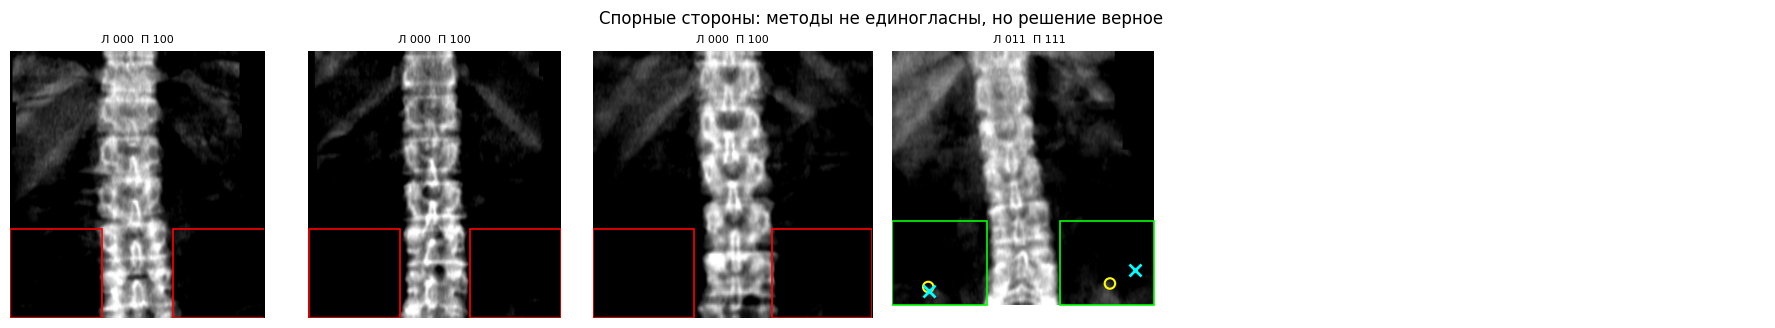

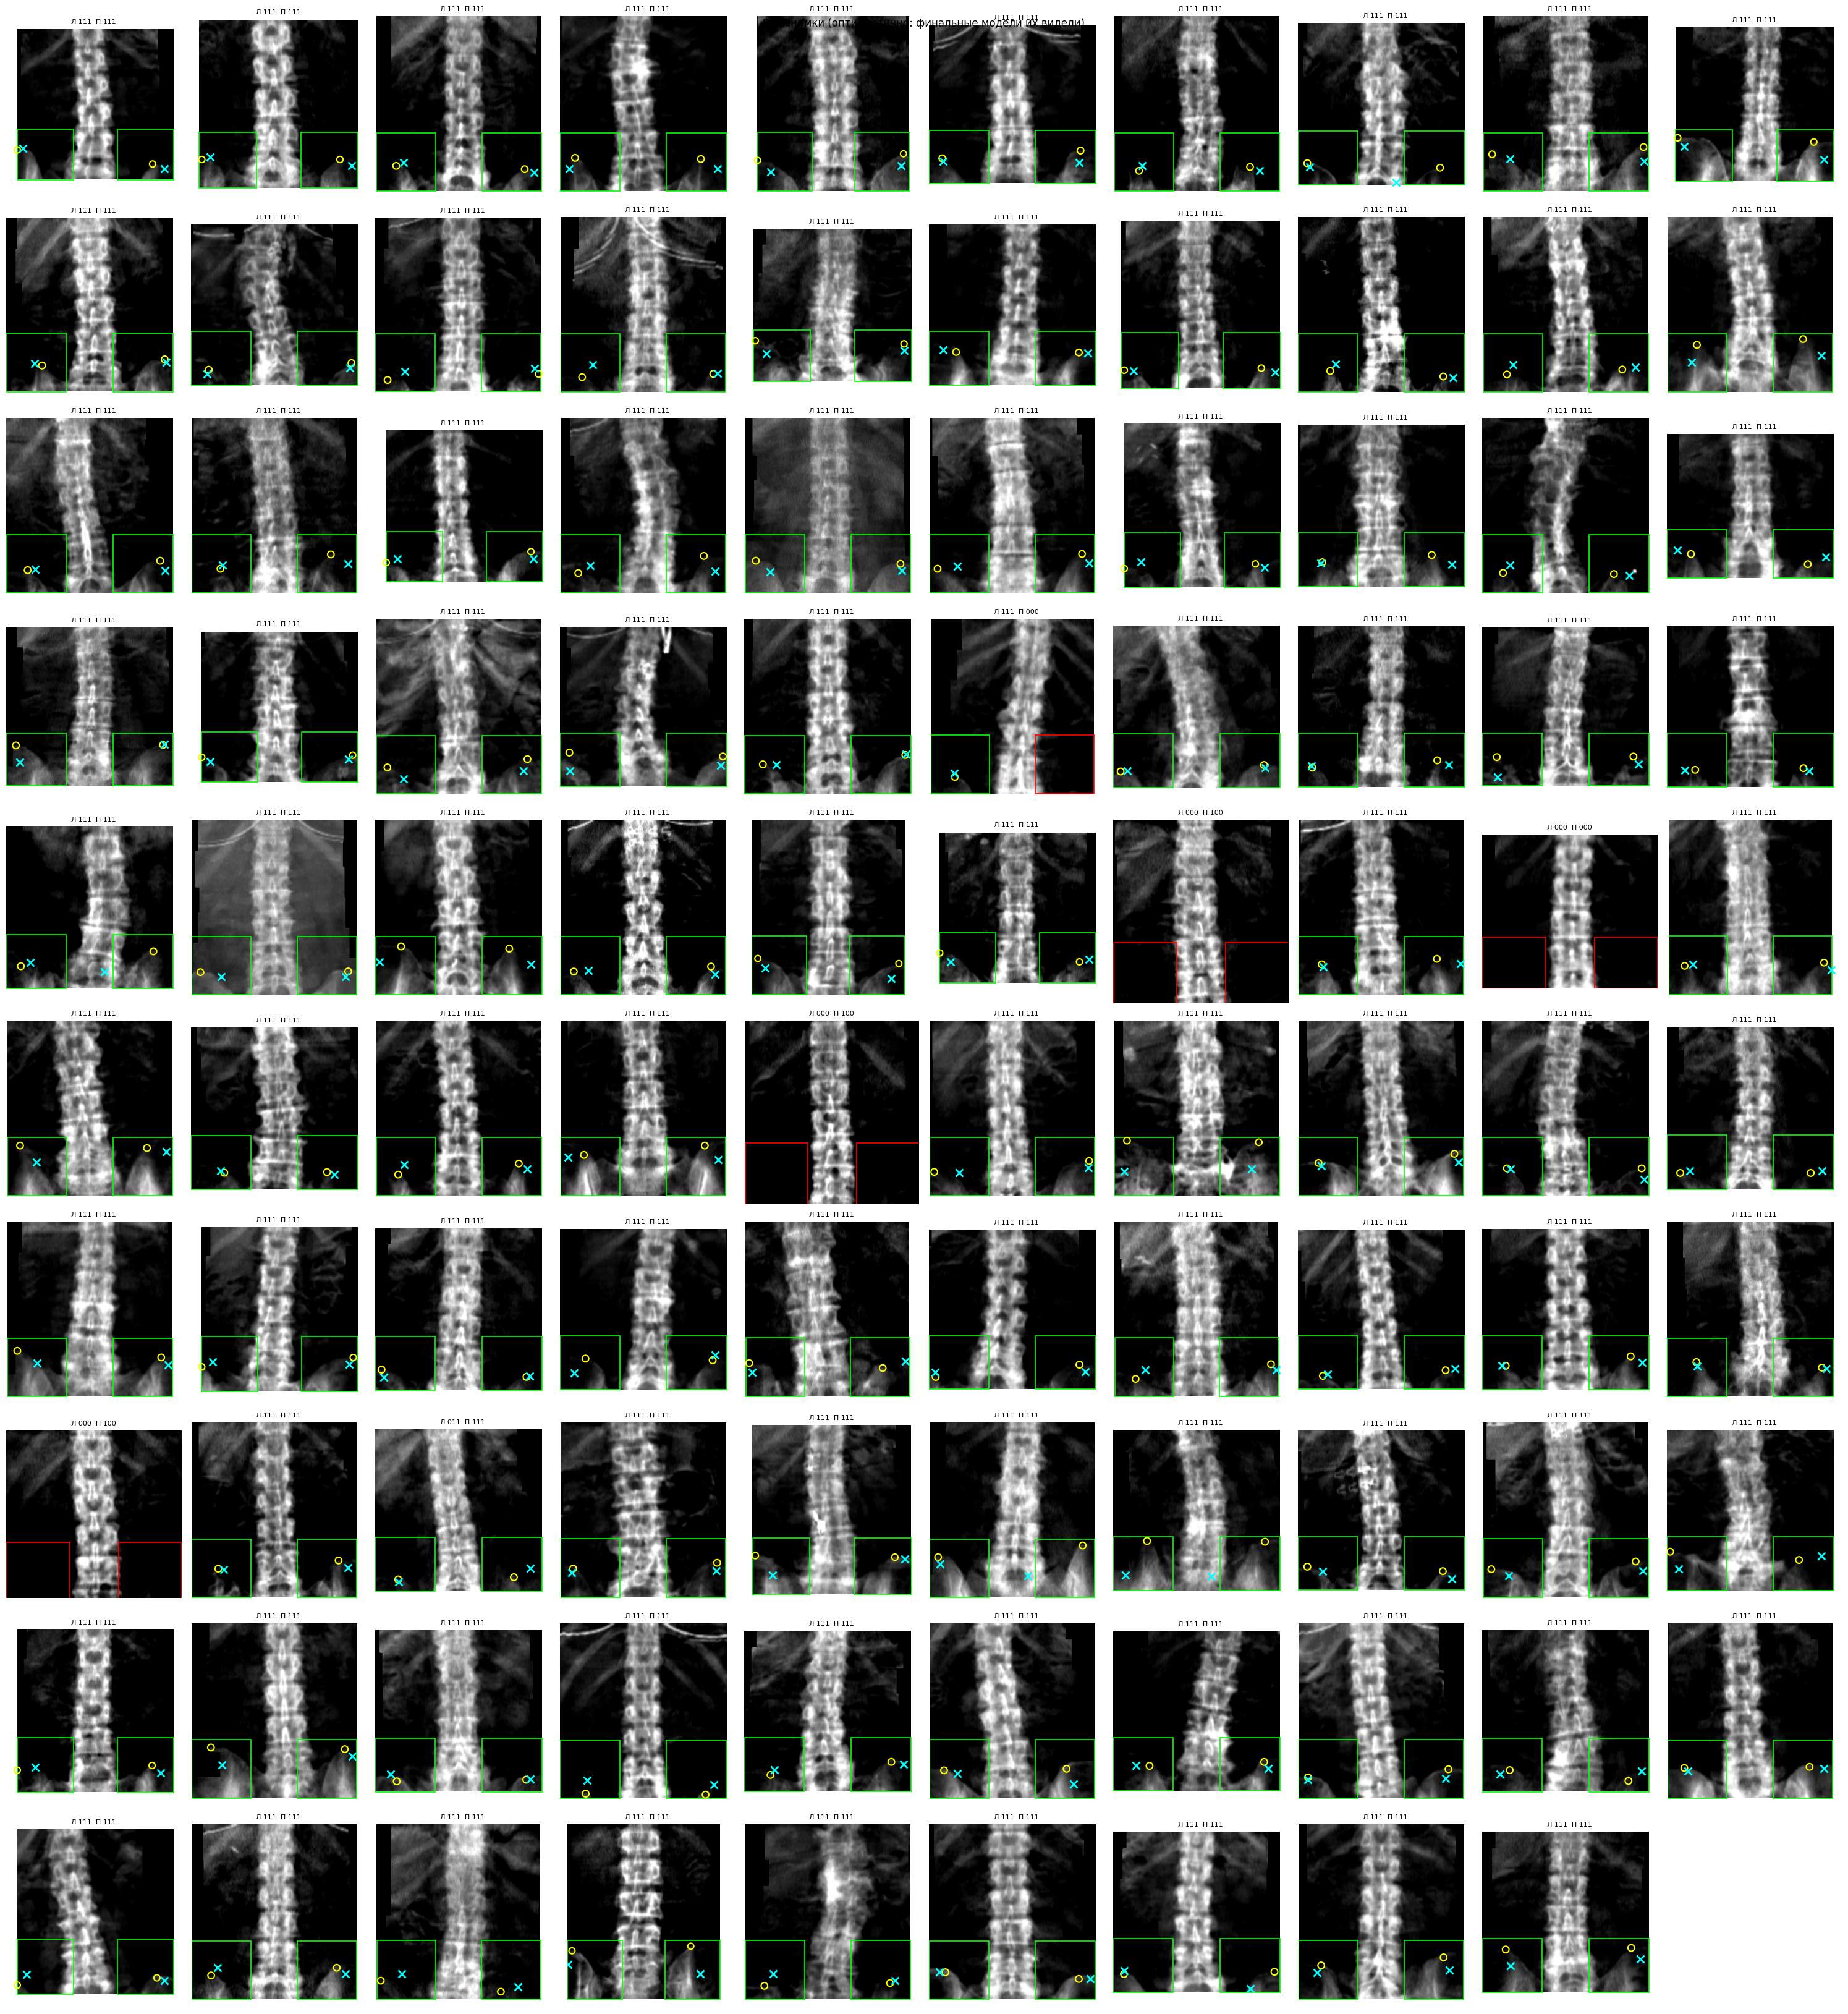

In [23]:
def draw_vote(ax, f: str, vd: pd.DataFrame):
    img = cv2.imread(os.path.join(IMAGES_DIR, f), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    man = manifest[manifest["image_filename"] == f].iloc[0]
    title = []
    for side in SIDES:
        r = vd[(vd.image_filename == f) & (vd.side == side)].iloc[0]
        x0, x1, y0 = crop_window(img, side)
        wrong = bool(r.vote) != bool(r.truth)
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, h - y0, fill=False, color="lime" if r.vote else "red", linewidth=3.5 if wrong else 1.2))
        gx, gy = CLS_COORD_COLS[side]
        if not pd.isna(man[gx]):
            ax.add_patch(plt.Circle((man[gx], man[gy]), 6, fill=False, color="yellow", linewidth=1.5))
        if r.vote and not pd.isna(r.x):
            ax.plot(r.x, r.y, "x", color="cyan", markersize=9, markeredgewidth=2)
        title.append(f"{'Л' if side == 'left' else 'П'} {int(r.keypoint)}{int(r.classifier)}{int(r.math)}")
    ax.set_title("  ".join(title), fontsize=8)


def show_vote(files: list, title: str, cols: int = 6, fname: str = None, dpi: int = 110):
    if not files:
        print(title, ": нечего показывать")
        return
    rows_n = math.ceil(len(files) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(3.0 * cols, 3.3 * rows_n))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, f in zip(axes, files):
        draw_vote(ax, f, vote_df)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    if fname:
        plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=dpi)
    plt.show()


wrong_files = sorted(vote_df[vote_df.vote != vote_df.truth.astype(bool)].image_filename.unique())
split_files = sorted(set(vote_df[vote_df[["keypoint", "classifier", "math"]].nunique(axis=1) > 1].image_filename) - set(wrong_files))
show_vote(wrong_files, "Ошибки решения (голосование)")
show_vote(split_files, "Спорные стороны: методы не единогласны, но решение верное")
show_vote(sorted(vote_df.image_filename.unique()), "Все снимки (оптимистично: финальные модели их видели)", cols=10, fname="vote_all.png", dpi=70)

## Что дальше

- **В прод:** keypoint-модель (`pelvis_crest_<backbone>.pt`), финальный классификатор (`pelvis_presence.pt`), порог математики `MATH_T_ALL` (число).
  Логика — `decide_sides(img)`: три голоса, решение по большинству, точка от keypoint.
- Решения по всем размеченным снимкам: `pelvis_vote_all.csv`.
- Если какой-то метод стабильно расходится с двумя другими на новых данных — это сигнал посмотреть снимок глазами.
- Порог классификатора `DECISION_THRESHOLD` и порог keypoint (`chosen_threshold`) выбраны по таблицам своих частей; реальных негативов мало, цифры по ним хрупкие.

## Пороги и параметры для пайплайна

Сохраняет `pelvis_crest_gate.json`: пороги трёх голосов (keypoint, классификатор, математика), число голосов для решения и параметры окна. Скачать вместе с весами.

In [24]:
import json

# Всё, что нужно прототипу пайплайна помимо весов: пороги трёх голосов и параметры окна. Файл кладётся рядом с весами (pelvis_crest_<backbone>.pt и pelvis_presence.pt).
gate = {
    "keypoint_backbone": KP_NAME, "keypoint_presence_threshold": float(KP_THR),
    "classifier_threshold": float(DECISION_THRESHOLD), "math_threshold": float(MATH_T_ALL), "vote_min": int(VOTE_MIN),
    "window": {"crop_top_frac": CROP_TOP_FRAC, "side_frac": SIDE_FRAC, "crop_size": CROP_SIZE, "crop_mode": CROP_MODE},
    "math": {"rows": MATH_ROWS, "outer": MATH_OUTER, "rel": MATH_REL},
    "keypoint_names": KEYPOINT_NAMES, "image_size": IMAGE_SIZE,
}
with open(os.path.join(OUTPUT_DIR, "pelvis_crest_gate.json"), "w", encoding="utf-8") as f:
    json.dump(gate, f, ensure_ascii=False, indent=1)
print(json.dumps(gate, ensure_ascii=False, indent=1))

{
 "keypoint_backbone": "convnext_tiny.fb_in22k_ft_in1k",
 "keypoint_presence_threshold": 0.97,
 "classifier_threshold": 0.7,
 "math_threshold": 0.05866835014419594,
 "vote_min": 2,
 "window": {
  "crop_top_frac": 0.667,
  "side_frac": 0.36,
  "crop_size": 128,
  "crop_mode": "spine"
 },
 "math": {
  "rows": 6,
  "outer": 0.7,
  "rel": 0.15
 },
 "keypoint_names": [
  "подвздошный_гребень_слева",
  "подвздошный_гребень_справа"
 ],
 "image_size": 224
}
